 Copyright © Sorbonne University.

 This source code is licensed under the MIT license found in the
 LICENSE file in the root directory of this source tree.

Vladislav ANTIPIN MIND 21242244
Milos OUNDJIAN MIND 21500050


# Outlook

In this notebook, we study basic linear and non-linear regression algorithms.
Regression is another name for function approximation, it consists in fitting a function to a set of points, as shown below.

The notebook is meant to study elements presented in lessons available in video here 
https://www.youtube.com/playlist?list=PLe5mY-Da-ksURGcelU-egwtWZXxVgZ76a

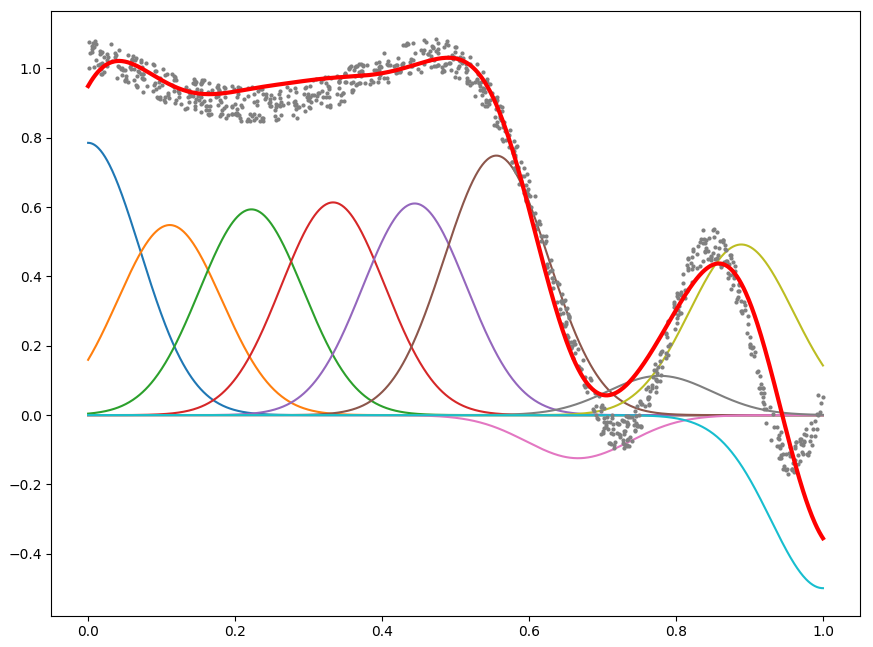


The notebook contains coding parts, where you have to code the main regression algorithms and check they work with a visualization,
and study parts, where you investigate their properties when changing some parameters or where you perform comparisons between methods. 
The study part may involve further coding to generate appropriate diagrams.

There are more studies than doable in a short time.
Do what you can among the studies. 
Doing one study accurately is better than being inaccurate on all studies.


# Installation

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

%pip install -q git+https://github.com/osigaud/regressionLabs

from regression_labs.batch import Batch
from regression_labs.latent_function import LinearLatentFunction, NonLinearLatentFunction, NonLinearLatentXDFunction
from regression_labs.gaussians import Gaussians

Note: you may need to restart the kernel to use updated packages.


# Introduction

The objective of regression or function approximation is to create a model from observed data. 
The model has a fixed structure with parameters (like the coefficients of a polynomial for instance), 
and regression consists in adjusting these parameters to fit the data. 
In machine learning, it is a very important technique since having a good model enables better predictions and performance.

With mathematical notations, given some datapoints $\{ ({\bf x}, {\bf y}) \}$, 
the goal is to adjust a model ${\bf y} = f({\bf x})$ so that the *learned* function $f$ accounts for these datapoints 
and generalize well to other unseen points $\{ ({\bf x}, {\bf y}) \}$.

The simplest case is linear regression, which assumes a relation of type ${\bf y} = {\bf A}{\bf x} + {\bf b}$ 
between the data ${\bf x}$ and ${\bf y}$.

Several methods exist to adjust the parameters ${\bf A}$ and ${\bf b}$, 
the most well-known being the least squares method (or least norm in the multivariate case).

In this lab, we assume that ${\bf y}$  is of dimension 1 (and write $y$ instead of ${\bf y}$  in what follows). 
This is a very common assumption.

Furthermore, in the code ${\bf x}$ is also of dimension 1, this is more restrictive 
as regression is often used from multidimensional input data.

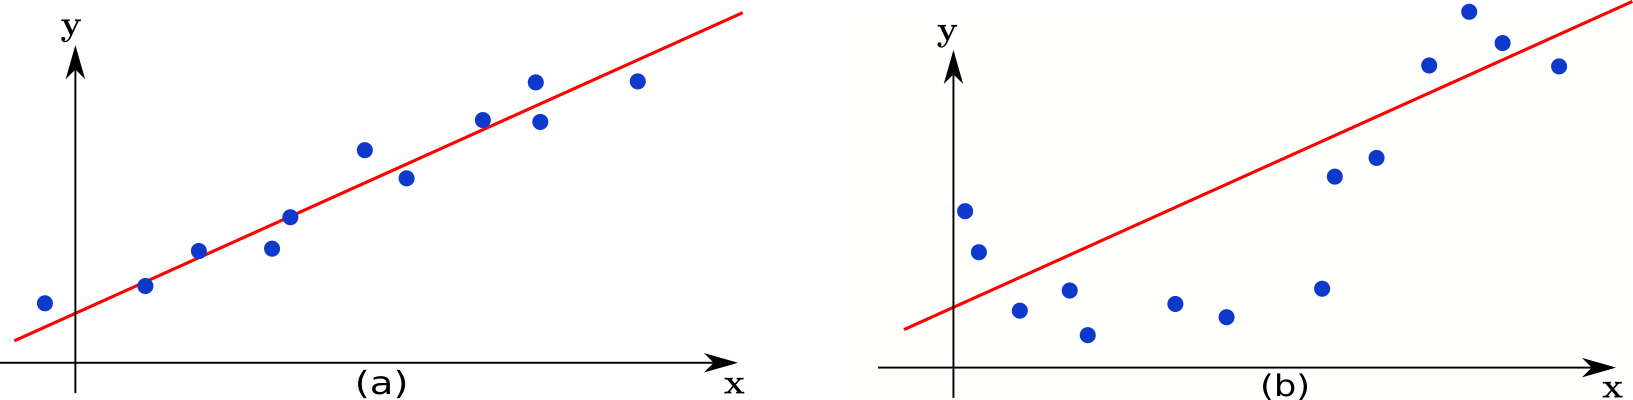


Often, linear models are not enough. For instance, see figures (a) and (b) above, 
on the left a linear regression is OK, but on the right it is not. 
In the case of (b), we must rely on nonlinear models. 
Here, we focus on the case where $f$ can be written as a sum of $k$ functions parametrized by vectors ${\mathbf{\theta}}_i$:

$$ f({\bf x})  = \sum_{i=1}^k f_{\mathbf{\theta}_i}({\bf x}).$$

In particular, we use Gaussian functions.

## Weighted sums of Gaussian functions

Gaussian functions $\phi_i({\bf x}) = \exp(-\frac{({\bf x}-{\bf c_i})^2}{\sigma_i^2})$ are almost equal to zero 
everywhere except in a neighborhood of ${\bf c_i}$, which represents the "center"' of the Gaussian (see the figure below). 
The value of $\sigma_i$ determines how large this neighborhood is.

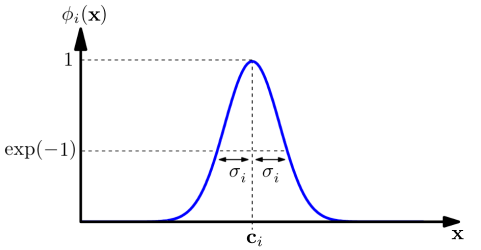

Then weighted Gaussian functions $f_{\mathbf{\theta}_i}$ can be written:

$$ f_{\mathbf{\theta}_i} = {\bf \theta}_i \phi_i({\bf x}) = {\bf \theta}_i \exp\left(-\frac{({\bf x}-{\bf c_i})^2}{\sigma_i^2}\right). $$

In RBFNs, the centers of the Gaussian functions are fixed in advance, and evenly distributed in the input space. 
Besides, all the $\sigma_i$'s are usually set to the same value.
Thus weighted Gaussian functions $f_{\mathbf{\theta}_i}$ have a unique scalar parameter 
which is their vector of weights $\mathbf{\theta}_i$.

# Provided code and documentation

The numpy reference guide is here: http://docs.scipy.org/doc/numpy/reference/

We provide a few useful classes and the infrastructure to perform these labs.

## Data generation

Two functions to generate points corresponding to a noisy linear and a noisy nonlinear model are provided in 
the ```LatentFunction``` class in the 
[latent_function.py](https://github.com/osigaud/regressionLabs/blob/main/regression_labs/latent_function.py) file.

## Batch of data

The [batch.py](https://github.com/osigaud/regressionLabs/blob/main/regression_labs/batch.py) file contains 
the ```Batch``` class. This class is used to collect a batch of linear or non-linear data, either in a single batch or incrementally.

## Vectors of Gaussian functions

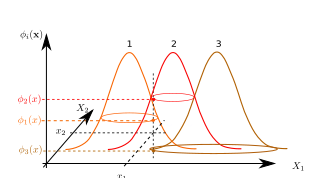

A ```Gaussians``` class is provided in [gaussians.py](https://github.com/osigaud/regressionLabs/blob/main/regression_labs/gaussians.py) 
to represent a vector of Gaussian feature functions $\phi({\bf x})$ of an input vector ${\bf x}$, 
as used in RBFNs and Locally Weighted Regression (LWR) (see below). 
The number $E$ of elements of $\phi({\bf x})$ (i.e. the number $E$ of Gaussian functions) is defined by the ```nb_features``` attribute. 

Given some input vector ${\bf x}$, the function ```phi_output(x)``` returns 
the vector of the output of (non-weighted) Gaussian functions applied to ${\bf x}$, thus a vector of size $E$.
In the particular case where $x$ is a scalar, it is transformed into a one element vector to keep consistent with the N-dimensional case.

Note that the input of the (multivariate) Gaussian functions is of the same dimension as ${\bf x}$, 
but their output is one-dimensional (see the figure above).

## Function approximators

We consider three families of approximation models: linear models , radial basis function networks and locally weigthed regression models. 
In all these models, the theta attribute represents the vector of parameters to be optimized. 
The ```f(self, x)``` function represents the function approximator output for a given input ```x```, to be optimized. 
The parameters used by $f$ are the elements of the ```theta``` vector.

For instance, for RBFNs, we consider a vector of $E$ Gaussian functions 
$\phi({\bf x}) = (\phi_1({\bf x}) \ \phi_2({\bf x}) \cdots \phi_E({\bf x}))^\intercal$, 
a vector of weights $\mathbf{\theta} = (\mathbf{\theta}_1 \ \mathbf{\theta}_2 \cdots \mathbf{\theta}_E)^\intercal$, 
and a vector of weighted Gaussian functions $f({\bf x}) = \phi({\bf x})^\intercal \mathbf{\theta}$.

These function approximation models come with various ```train_...(self, ...)``` functions that you must fill.

# Visualization

For all the regression methods described below, as illustrated in the figure at the top of this notebook, 
after executing it, the observed data are shown by points, and the red curve is the *learned* function $f$ 
corresponding to the parameters $\mathbf{\theta}$ that have been incrementally adjusted. 
When this applies, the other curves correspond to the $f_{\mathbf{\theta}_i}({\bf x})$ functions, 
they show the decomposition of $f$, which is the sum of all these functions. 
All visualization functions are in the ```plot()``` function of each approximator.

# Notations and code helpers

We consider either a batch regression approach, an iterative one or an incremental one. In the batch and iterative approaches, we consider a batch of data consisting of $N$ $\{ ({\bf x}_i, y_i) \}_{1 \leq i \leq N}$ pairs.
In the incremental one, we get an additional pair of data $({\bf x}^{(t)}, y^{(t)})$ at each time step $t$.

In the general case, an input datapoint ${\bf x}$ is of dimension $d$, and we have ${\bf x} = (x_1 \ x_2 \cdots x_d)^\intercal$.
Under algebraic form, the batch of data is rewritten $({\bf X}, {\bf y})$ where ${\bf X}$ is a $N \times d$ matrix and ${\bf y}$ is a $N$ dimensional vector.

## Issues with ```transpose()``` in numpy

In regression algorithms, we often use the transpose operator.
But in numpy, transposing a standard one-dimensional vector does not work as expected: the result of the tranpose operator is the same vector, which is quite unfortunate.

Below we define two functions to fix this issue.

In [4]:
import numpy as np

def horiz_to_verti(vec):
  return vec.reshape(-1, 1)

def verti_to_horiz(vec):
  return vec.reshape(-1)

And here is a small example about how to use it.

In [5]:
vec = np.zeros(3)
print(vec)
v2 = vec.transpose()
print ("incorrect transpose:", v2)
v3 = horiz_to_verti(vec)
print ("correct transpose:", v3)
v4 = verti_to_horiz(v3)

print ("transpose of the transpose:", v4)

[0. 0. 0.]
incorrect transpose: [0. 0. 0.]
correct transpose: [[0.]
 [0.]
 [0.]]
transpose of the transpose: [0. 0. 0.]


## Augmenting the design matrix with one dimension

To solve a linear least square problem, we want to use a model of the form $f_\mathbf{\theta}({\bf X}) = \mathbf{\theta}^\intercal{\bf X} + {\bf b}$.
To deal more elegantly with the intercept ${\bf b}$, we extend the vectors ${\bf x}$ with an additional dimension
using $\bar{\bf x}_i = (x_{i,1} \ x_{i,2} \cdots x_{i,d} \ 1)^\intercal$, and we redefine the augmented design matrix as

$$\bar{\bf X}=\left(
\begin{array}{ccccc}
 x_{1,1}&x_{1,2}&\cdots &x_{1,d} &1\\
 x_{2,1}&x_{2,2}&\cdots &x_{2,d} &1\\
 \vdots  &\vdots  &\ddots &\vdots   &\vdots\\
 x_{N,1}&x_{N,2}&\cdots &x_{N,d} &1\\
\end{array}
\right).
$$

This way, our model can be rewritten $f_\mathbf{\theta}({\bf X}) = \mathbf{\theta'}^\intercal{\bar{\bf X}}$.

From the list of vectors *x_data* provided by the sample generator, $\bar{\bf X}$ can be obtained by first transforming *x_data* into a *numpy array* and transposing using

```x_data = numpy.array(x_data).transpose()```,

and then adding the ones with:

```barX = np.hstack((x_data, numpy.ones((x_data.shape[0], 1))))```

Let us define the ```bar_design()``` function

In [6]:
def bar_design(x):
  return np.hstack((x, np.ones((x.shape[0], 1))))

And check that it works.

In [7]:
lf = LinearLatentFunction()
batch = lf.get_batch(5)
barX = bar_design(batch.x_data)
print ("input:", batch.x_data)
print ("Augmented design matrix:", barX)

input: [[0.4485878 ]
 [0.72295174]
 [0.14554871]
 [0.12760952]
 [0.3004856 ]]
Augmented design matrix: [[0.4485878  1.        ]
 [0.72295174 1.        ]
 [0.14554871 1.        ]
 [0.12760952 1.        ]
 [0.3004856  1.        ]]


# Coding and study of regression algorithms

We now investigate four families of regression algorithms: 
- the Linear Least Squares (LLS),  
- Radial Basis Function Networks (RBFNs) using various fitting algorithms, 
- regression with neural networks,
- Locally Weighted Regression (LWR).

# Linear Least squares

## Coding part

### Batch Linear Least squares

The linear least squares method finds the best linear model from a batch of data, using

$$  \mathbf{\theta}^* = \min_{\mathbf{\theta}} \underbrace{\|{\bf y}-\mathbf{\theta}^\intercal\bar{\bf X}\|^2}_{L(\mathbf{\theta})}.$$

The parameters for the optimal model are given by:

$$ \mathbf{\theta}^* = (\bar{\bf X}^\intercal\bar{\bf X})^{-1}{\bar{\bf X}}^\intercal{\bf y}.$$

The code below provides the ```Line``` class. The way to get the linear least square model using *stats.linregress(x_data, y_data)* is given in the ```train_from_stats(self, x_data, y_data)``` function. In this provided function, **you just need to print the obtained values and set the ```self.theta``` attribute correctly**.

Then, fill the ```train(self, x_data, y_data)``` function so as to perform the same linear least square computation using the above equation, **without** using ```stats.linregress(x_data, y_data)```.

In [8]:
from scipy import stats

class LinearModel:
    def __init__(self, batch_size):
        self.nb_dims = 1
        # We add one to add the offset in the end of the vector
        self.theta = np.zeros(self.nb_dims + 1)

    def f(self, x):
        """
        Get the output of the function approximator for a given vector of input variables
        :param x: A single vector of input variables with size [Ns]
        :returns: the function approximator output
        """
        x_bar = bar_design(x)
        return np.dot(x_bar, self.theta)

    # -- compute the residuals --#
    def compute_error(self, x_data, y_data):
      error = np.linalg.norm(y_data-self.f(x_data))
      return error

    # ----------------------#
    ## Training Algorithms ##
    # ----------------------#

    def train_from_stats(self, x_data, y_data):
        # Finds the Least Square optimal weights: python provided version
        slope, intercept, r_value, _, _ = stats.linregress(verti_to_horiz(x_data), y_data)

        print("slope :", slope)
        print("intercept :", intercept)
        print("r_value :", r_value)

        # To be completed...
        self.theta = np.array([slope, intercept])


    def train(self, x_data, y_data):
        # Finds the Least Square optimal weights

        # To be completed...
        x_bar = bar_design(x_data)
        self.theta = verti_to_horiz(np.linalg.inv(x_bar.T@x_bar) @ x_bar.T @ horiz_to_verti(y_data))


    def train_regularized(self, x_data, y_data, coef):
        # Finds the regularized Least Square optimal weights

        # To be completed...
        x_bar = bar_design(x_data)
        self.theta = verti_to_horiz(np.linalg.inv(coef*np.eye(self.nb_dims+1)+x_bar.T@x_bar) @ x_bar.T @ horiz_to_verti(y_data))


    # -----------------#
    # # Plot function ##
    # -----------------#

    def plot(self, x_data, y_data, title):
        xs = np.linspace(0.0, 1.0, 1000)
        z = []
        for i in xs:
            z.append(self.f(np.array([[i]])))

        plt.plot(x_data, y_data, 'o', markersize=3, color='lightgreen')
        plt.plot(xs, z, lw=2, color='red')
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()

Visualize whether your code works.

theta: [ 2.65188493 -3.7588947 ]
LLS time: 0.0014889999999998516


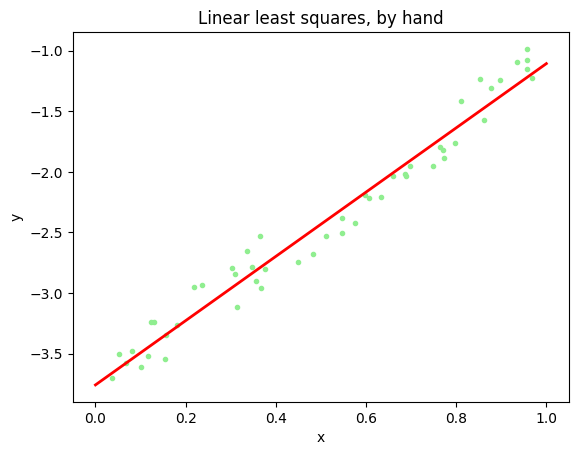

slope : 2.65188492838423
intercept : -3.7588946995053334
r_value : 0.9835148113721781
theta: [ 2.65188493 -3.7588947 ]
LLS from scipy stats time: 0.0004780000000002005


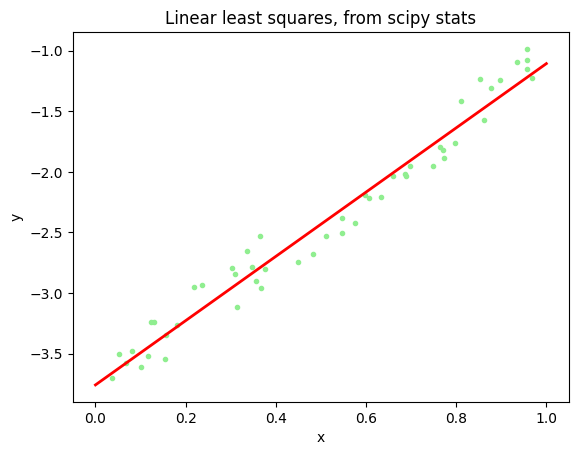

In [9]:
lf = LinearLatentFunction()
size = 50
batch = lf.get_batch(size)
model = LinearModel(size)

start = time.process_time()
x = np.array(batch.x_data)
y = np.array(batch.y_data)
model.train(x, y)
print("theta:", model.theta)
print("LLS time:", time.process_time() - start)
model.plot(x, y, "Linear least squares, by hand")

start = time.process_time()
model.train_from_stats(x, y)
print("theta:", model.theta)
print("LLS from scipy stats time:", time.process_time() - start)
model.plot(x, y, "Linear least squares, from scipy stats")

### Ridge Regression

The ridge regression (or regularized least squares, or Tikhonov regularization) method finds the best linear model from a batch of data, but ensuring that the obtained weights are not too high, using

$$ \mathbf{\theta}^* = \min_{\mathbf{\theta}} \underbrace{[\frac{\lambda}{2}||\mathbf{\theta}||^2 + \frac{1}{2}\|{\bf y}-\mathbf{\theta}^\intercal\bar{\bf X}\|^2]}_{L(\mathbf{\theta})}.$$

The parameters for the optimal model are given by:

$$ \mathbf{\theta}^* = (\lambda \mathbf{I} + \bar{\bf X}^\intercal\bar{\bf X})^{-1}{\bar{\bf X}}^\intercal{\bf y}.$$

In the Line class above, fill the `train_regularized(self, x_data, y_data, coef)` function.

And check that it works with a new batch of data

theta regularized: [ 2.64136881 -3.75281225]
regularized LLS : 0.00023499999999998522


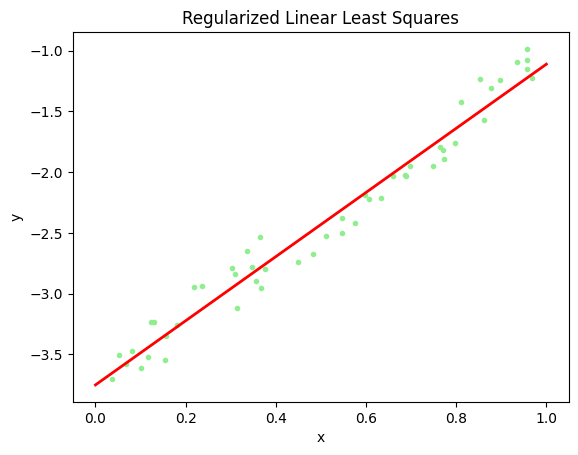

In [10]:
# We use the same batch as before, uncomment if you want to use another batch
# lf = LinearLatentFunction()
# size = 50
# batch = lf.get_batch(size)
model = LinearModel(size)

start = time.process_time()
model.train_regularized(batch.x_data, batch.y_data, coef=0.01)
print("theta regularized:", model.theta)
print("regularized LLS :", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "Regularized Linear Least Squares")

## Study part: linear least squares

### Key study: impact of regularization

For a batch of 50 points, study with the` train_regularized(self,x_data,y_data,coef)` function 
how the residuals degrade as you increase the value of ```coef``` in some well chosen range. 
Explain what you see. A good idea would be to make a picture with coef in the x axis and the residuals in the y axis, 
and then to comment it. Having a look at the learned model may also help.

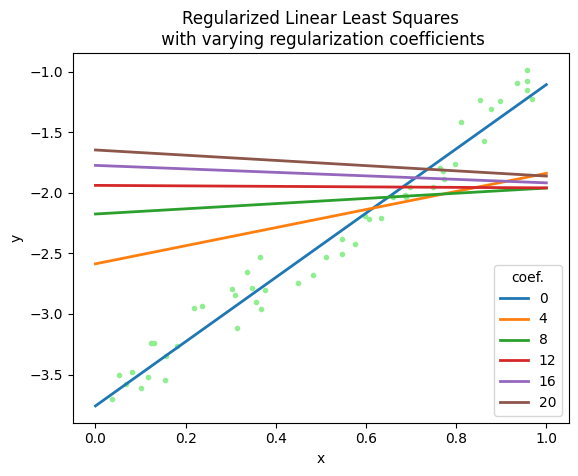

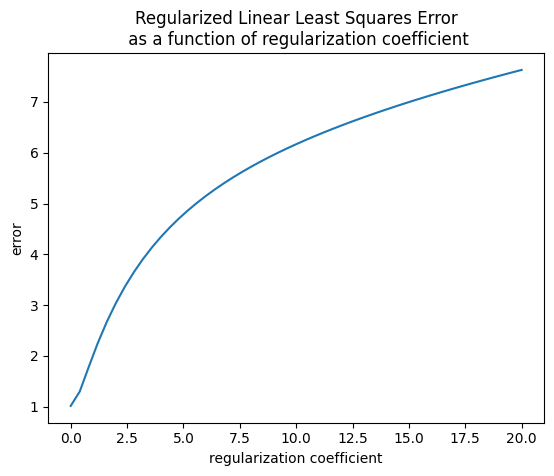

In [11]:
# We use the same batch as before, uncomment if you want to use another batch
# lf = LinearLatentFunction()
# size = 50
# batch = lf.get_batch(size)
coefs = np.linspace(0,20, 51)
model = LinearModel(size)
errors = []

plt.plot(batch.x_data, batch.y_data, 'o', markersize=3, color='lightgreen')
for i, coef in enumerate(coefs):
    model.train_regularized(batch.x_data, batch.y_data, coef=coef)
    errors.append(model.compute_error(batch.x_data, batch.y_data))
    if i % 10 == 0:
        xs = np.linspace(0.0, 1.0, 1000)
        z = []
        for i in xs:
            z.append(model.f(np.array([[i]])))
        plt.plot(xs, z, lw=2, label= f"{coef:.2g}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(title="coef.")
plt.title("Regularized Linear Least Squares\n with varying regularization coefficients")
plt.show()

plt.plot(coefs, errors)
plt.xlabel("regularization coefficient")
plt.ylabel("error")
plt.title("Regularized Linear Least Squares Error\n as a function of regularization coefficient")
plt.show()

We can see that residuals gradually degrade as regularization coefficient increases. Indeed, larger regularization coefficient results in smaller parameter estimates compared to model without regularization. The graphs of fitted models show that - we observe smaller intercepts and slopes of fitted lines (they appear "flatter"). Even though training error increases, doing this can improve model generalization - reduce test error.

### Optional study: comparing your LLS code and train_from_stats

Does your ```train(self, x_data, y_data)``` function provide exactly the same results 
as the ```train_from_stats(self, x_data, y_data)``` function?
Call both functions 1000 times with batches containing between 5000 and 50.000 data points and compare their run time with a figure.
Explain what you see.

In [12]:
lf = LinearLatentFunction()
times = {"manual": [],
         "stats": []}
sizes = np.linspace(5_000, 50_000, 10, dtype=int)
for size in sizes:
    times["manual"].append([])
    times["stats"].append([])
    for _ in range(100):
        batch = lf.get_batch(size)
        model = LinearModel(size)

        start = time.process_time()
        x = np.array(batch.x_data)
        y = np.array(batch.y_data)
        model.train(x, y)
        times["manual"][-1].append(time.process_time() - start)

        start = time.process_time()
        model.train_from_stats(x, y)
        times["stats"][-1].append(time.process_time() - start)

slope : 2.4241764996120887
intercept : -0.6539621199534467
r_value : 0.9797415380925505
slope : 2.4188256943245503
intercept : -0.6521109672331962
r_value : 0.9790410856601958
slope : 2.4323046670556816
intercept : -0.6560077816837766
r_value : 0.9791253229578786
slope : 2.408152829612894
intercept : -0.6428175419713545
r_value : 0.9786836194036876
slope : 2.418039025427487
intercept : -0.6485982679675262
r_value : 0.9790786796586608
slope : 2.41342705290222
intercept : -0.6457293246719372
r_value : 0.9790455360890371
slope : 2.409336582198426
intercept : -0.6413011658619677
r_value : 0.9787547875516642
slope : 2.4059460834722346
intercept : -0.6430127373480908
r_value : 0.9790553394820429
slope : 2.409661235541234
intercept : -0.6423279741583392
r_value : 0.9795449875996003
slope : 2.4084051372878434
intercept : -0.6449850937583014
r_value : 0.9790201317911951
slope : 2.418750651600909
intercept : -0.6474449495974086
r_value : 0.9791869628953748
slope : 2.4177875123412766
intercept : 

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/950372716.py:44: RuntimeWarning: divide by zero encountered in matmul
  self.theta = verti_to_horiz(np.linalg.inv(x_bar.T@x_bar) @ x_bar.T @ horiz_to_verti(y_data))
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/950372716.py:44: RuntimeWarning: overflow encountered in matmul
  self.theta = verti_to_horiz(np.linalg.inv(x_bar.T@x_bar) @ x_bar.T @ horiz_to_verti(y_data))
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/950372716.py:44: RuntimeWarning: invalid value encountered in matmul
  self.theta = verti_to_horiz(np.linalg.inv(x_bar.T@x_bar) @ x_bar.T @ horiz_to_verti(y_data))


slope : 2.4058092336588155
intercept : -0.6422091267175316
r_value : 0.979184825199153
slope : 2.407627450580967
intercept : -0.6417736010344205
r_value : 0.9791443014921263
slope : 2.405552615685996
intercept : -0.6411348435958403
r_value : 0.9794388073036141
slope : 2.4086349295281906
intercept : -0.6393373625868221
r_value : 0.9794923929298123
slope : 2.415983462076019
intercept : -0.6495200084420115
r_value : 0.9790238993989324
slope : 2.405980933670526
intercept : -0.6412827252101483
r_value : 0.9792941617983556
slope : 2.405730739366238
intercept : -0.6406416820352291
r_value : 0.9787621595682142
slope : 2.4195861051996257
intercept : -0.644595011164122
r_value : 0.9796143001235017
slope : 2.414210865152583
intercept : -0.6483233316193447
r_value : 0.9795213757723328
slope : 2.417861049730908
intercept : -0.6504475952210366
r_value : 0.9797067423717046
slope : 2.4202259773595567
intercept : -0.6500294958256218
r_value : 0.9798136986861355
slope : 2.420267920918592
intercept : -0.

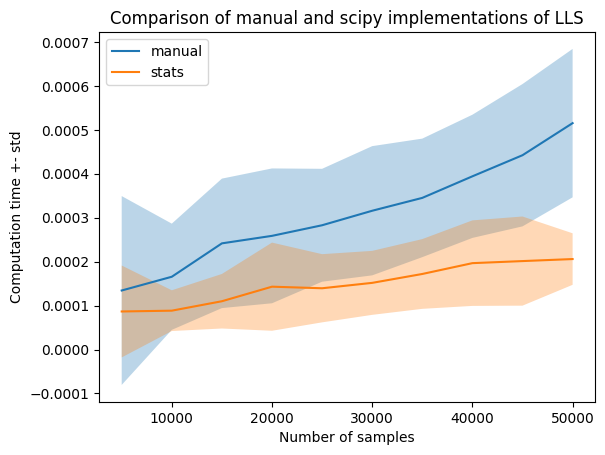

In [13]:
for model_name in times.keys():
    all_times = np.array(times[model_name])
    means, stds = all_times.mean(axis=1), all_times.std(axis=1)
    plt.plot(sizes, means, label=model_name)
    plt.fill_between(sizes, means-stds, means+stds, alpha=0.3)
plt.title("Comparison of manual and scipy implementations of LLS")
plt.xlabel("Number of samples")
plt.ylabel("Computation time +- std")
plt.legend()
plt.show()

Both implementations of LLS obviously take more computation time for larger batches of data. Our manual version of linear least squares regression is nevertheless slower that one of `scipy.stats.linregress`, because it uses the closed form solution for this specific case involving the computation of means and standard deviations which is more efficient than inverting a matrix.

# Radial Basis Function Networks

## Coding part

Let us now code Radial Basis Function Networks (RBFNs). 
We implement several regression techniques with these models: batch least squares, 
gradient descent, and recursive least squares. 
We first define a general purpose RBFN class that encodes the vector of parameters $\theta$, 
the function $\phi(x)$, a function to compute the error of a model and a plotting function.

In [14]:
color_map = ["yellow","brown","orange","green","cyan","pink","red","blue","black","violet"]

class RBFN(Gaussians):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        self.theta = np.zeros(self.nb_features)

    def f(self, x):
        """
        Get the output of the function approximator for a given vector of input variables
        :param x: A vector of input variables of size N
        :return: A vector of function approximator outputs with size the number of x datapoints
        """
        f = np.dot(self.phi_output(x).transpose(), self.theta)
        return f

    def feature(self, x, idx):
        """
        Get the output of the idx^th feature for a given input vector
        This is function f() considering only one feature
        Used mainly for plotting the features

        :param x: A vector of dependent variables of size N
        :param idx: index of the feature

        :return: the value of the feature for x
        """
        phi = self.phi_output(x)
        return phi[idx] * self.theta[idx]

    # -- compute the residuals --#
    def compute_error(self, x_data, y_data):
        """
        Compute the residuals (squared sum of errors) over all the dataset
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint

        :return: the residuals of the data given the model
        """
        error = np.linalg.norm(y_data - self.f(x_data))
        return error

    # ------ Plot function -------#
    def plot(self, x_data, y_data, title):
        """
        Given a dataset x_data, y_data, plots the points of the dataset, 
        the feature functions multiplied by their weight parameter 
        and the resulting model of the latent function
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint

        :return: nothing
        """
        size = 500
        xs = np.linspace(0.0, 1.0, size)
        z = []
        for i in xs:
            z.append(self.f(np.array([i])))

        z2 = []
        for i in range(self.nb_features):
            temp = []
            for j in xs:
                temp.append(self.feature(np.array([j]), i))
            z2.append(temp)
            plt.plot(xs, z2[i], color=color_map[i%10])
        plt.plot(x_data, y_data, 'o', markersize=3, color='lightgreen')
        plt.plot(xs, z, lw=3, color='red')
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()

### Batch RBFNs

When applied to RBFNs, there are two perspectives about the batch least squares method.

#### First perspective

The **first perspective** considers that the RBFN is used to project from an input space into a feature space, 
before performing the standard linear least square calculation in this projected space.

Thus, from the batch of data we build the Gram matrix ${\bf G}$, projecting each datapoint $(x_i)_{1 \leq i \leq N}$ 
into its output vector for all the features $(\phi_j({\bf x}_i))_{1 \leq j \leq E}$. 
Then we apply the standard linear least square method, replacing the augmented design matrix $\bar{\bf X}$ with the Gram matrix ${\bf G}$:

$$  \mathbf{\theta}^* = ({\bf G}^\intercal{\bf G})^{-1}{{\bf G}}^\intercal{\bf y}.$$

This is the easiest approach to code in python.

In the code of the ```BatchRBFN1``` class below, fill the ```train_ls(self, x_data, y_data)``` function.

In [15]:
class BatchRBFN1(RBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)

    # ------ batch least squares first perspective) ---------
    def train(self, x_data, y_data): 
        
        # To be completed...
        G = self.phi_output(x_data).transpose()
        self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
        


### Second perspective

In the **second perspective**, we perform the whole calculation from scratch. We want to minimize the following error:
$$\epsilon(\mathbf{\theta}) = \frac{1}{2N}\sum_{i=1}^N (y_i - f_{\mathbf{\theta}}({\bf x}_i))^2.$$

To get a local minimum over $\mathbf{\theta}$ of the function $\epsilon(\mathbf{\theta})$, 
we need to solve $\nabla_\mathbf{\theta} \epsilon(\mathbf{\theta}) = {\bf 0}$.
To compute the gradient, we use $\nabla (g^2) = 2g\nabla g$. Therefore, we have

$$\nabla_\mathbf{\theta} \epsilon(\mathbf{\theta}) = \frac{1}{N}\sum_{i=1}^N  \left(y_i - f_{\mathbf{\theta}}\big( {\bf x}_i\big)\right)\nabla_\mathbf{\theta} f_{\mathbf{\theta}}({\bf x}_i).$$

Since $f_{\mathbf{\theta}}({\bf x}) = \phi({\bf x})^\intercal \mathbf{\theta}$, 
we have $\nabla_\mathbf{\theta} f_{\mathbf{\theta}}({\bf x}_i) = \phi({\bf x}_i)$ and we get

$$\nabla_\mathbf{\theta} \epsilon(\mathbf{\theta}) = \frac{1}{N}\sum_{i=1}^N  \left(y_i - \phi({\bf x}_i)^\intercal \mathbf{\theta}\right)\phi({\bf x}_i)$$

To make the gradient $\nabla_\mathbf{\theta} \epsilon(\mathbf{\theta}) = {\bf 0}$, we get:

$$\frac{1}{N}\sum_{i=1}^N \left(y_i - \phi({\bf x}_i)^\intercal \mathbf{\theta}\right)\phi({\bf x}_i) = 0$$

$$\frac{1}{N}\sum_{i=1}^N \left(\phi({\bf x}_i)y_i - \phi({\bf x}_i) \phi({\bf x}_i)^\intercal \mathbf{\theta}\right) = 0$$

$$\left( \sum_{i=1}^N \phi({\bf x}_i) \phi({\bf x}_i)^\intercal \right) \mathbf{\theta} = \sum_{i=1}^N \phi({\bf x}_i) y_i.$$

Let us set

$${\bf A} = \left( \sum_{i=1}^N \phi({\bf x}_i) \phi({\bf x}_i)^\intercal \right)$$

and $${\bf b} = \sum_{i=1}^N \phi({\bf x}_i) y_i.$$

We then have ${\bf A} \mathbf{\theta} = {\bf b}$.

${\bf A}$ is not necessarily an invertible matrix, and the general solution is obtained as $\mathbf{\theta} = A^\sharp b$, 
by using either the ``pseudo-inverse'' $A^\sharp$ ```(np.linalg.pinv(A))``` or using ```theta = np.linalg.solve(A,b)```.

In the ```BatchRBFN2``` class below, fill the code of the ```train(self, x_data, y_data)``` function according to the above perspective.

In [16]:
class BatchRBFN2(RBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)

    # ------ batch least squares (second perspective) ---------
    def train(self, x_data, y_data):
        
        # To be completed...
        G = self.phi_output(x_data).transpose()
        # Note that following formulas are equivalent to those from BatchRBFN1
        # (just matrix operations are developed)
        # the on;y important different - usage of pinv() instead of inv()
        A = np.sum([ np.outer(phi, phi) for phi in G], axis=0) # equivalently: G.T @ G
        b = G.T @ y_data
        self.theta = np.linalg.pinv(A)@b


Now, run the code below to see if yours works.

theta ls1 : [1.38717671 0.94751941 1.09548037 0.87106566 0.95808302 0.82642387
 0.86730607 0.82371433 0.70048594 0.77938245]
error :  0.25447511687512214
RBFN LS time: 0.0017639999999978784


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: divide by zero encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: overflow encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: invalid value encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data


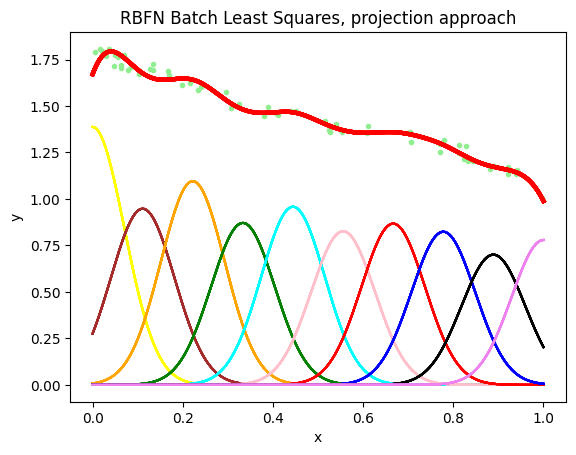

theta ls2 : [1.38717671 0.94751941 1.09548037 0.87106566 0.95808302 0.82642387
 0.86730607 0.82371433 0.70048594 0.77938245]
error :  0.25447511687512214
RBFN LS2 time: 0.001277000000001749


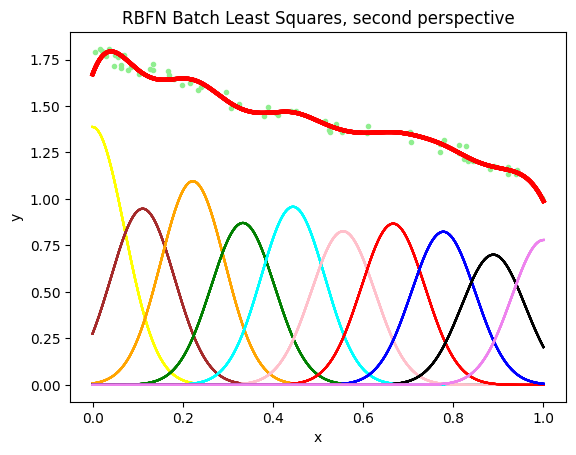

In [17]:
lf = NonLinearLatentFunction()
size = 60
batch = lf.get_batch(size)
model = BatchRBFN1(nb_features=10)

start = time.process_time()
model.train(batch.x_data, batch.y_data)
error = model.compute_error(batch.x_data, batch.y_data)
print("theta ls1 :", model.theta)
print("error : ", error)
print("RBFN LS time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "RBFN Batch Least Squares, projection approach")

model = BatchRBFN2(nb_features=10)
start = time.process_time()
model.train(batch.x_data, batch.y_data)
error = model.compute_error(batch.x_data, batch.y_data)
print("theta ls2 :", model.theta)
print("error : ", error)
print("RBFN LS2 time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "RBFN Batch Least Squares, second perspective")

###  Incremental RBFNs

For this part we define a general purpose IncrRBFN class that we derive below in different subclasses to implement the various algorithms.

In [18]:
class IncrRBFN(RBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        self.theta = np.random.random(self.nb_features)
        #print(self.theta)

    def f(self, x, theta=None):
        """
        Get the output of the function approximator for a given vector of input variables 
    
        :param x: A vector of dependent variables of size N
        :param theta: A vector of coefficients to apply to the features. 
        :If left blank the method will default to using the trained thetas in self.theta.
        
        :return: A vector of function approximator outputs with size nb_features
        """
        if not hasattr(theta, "__len__"):
            theta = self.theta
        value = np.dot(self.phi_output(x).transpose(), theta)
        return value

    # -------- this function will be redefined in subclasses -----------------
    def train(self, x, y, alpha):
        raise NotImplementedError

#### Gradient Descent

Let the vector $\mathbf{\theta}^{(t)}$ be the value of the parameters of the regression model at iteration $t$. 
We observe some new data $({\bf x}^{(t+1)}, y^{(t+1)})$.
The error of the current model on this pair is
$$\epsilon^{(t+1)} = y^{(t+1)} - f_{\mathbf{\theta}}( {\bf x}^{(t+1)}).$$

The idea of gradient descent is to slightly modify $\mathbf{\theta}$ to decrease $\epsilon^{(t+1)}$.

To do so, we consider the function $\mathbf{\theta} \mapsto y^{(t+1)} - f_{\mathbf{\theta}}\left( {\bf x}^{(t+1)}\right)$ and compute its gradient in $\mathbf{\theta}^{(t+1)}$, which we denote by $\nabla_\mathbf{\theta}^{(t+1)}$.

Since we have $f_{\mathbf{\theta}}({\bf x}) = \phi({\bf x})^\intercal \mathbf{\theta}$, 
we get $\nabla_\mathbf{\theta}^{(t+1)} = - \phi({\bf x}^{(t+1)})$.

The gradient of a function is oriented towards the direction of steepest increase. 
This means that it gives the direction in which a small modification of the vector 
of inputs leads to the largest increase of the function output. 
The opposite direction is the one of steepest decrease.

Here, the goal is to decrease $\epsilon^{(t+1)}$ thus $\mathbf{\theta}^{(t+1)}$ should be modified 
in the direction defined by $- \nabla_{\mathbf{\theta}}^{(t+1)} =  \phi({\bf x}^{(t+1)})$.
The resulting update formula is

\begin{align*}
 \mathbf{\theta}^{(t+1)} &= \mathbf{\theta}^{(t)} + \alpha \epsilon^{(t+1)} \nabla_{\mathbf{\theta}}^{(t+1)} \\
 &= \mathbf{\theta}^{(t)} + \alpha (y^{(t+1)} - f_{\mathbf{\theta}}( {\bf x}^{(t+1)})) \phi({\bf x}^{(t+1)})^\intercal \\
\end{align*}

where $\alpha > 0$ is a coefficient called the ``learning rate''.

Using $f_{\mathbf{\theta}}({\bf x}) = \phi({\bf x})^\intercal \mathbf{\theta}$, we can also write it:
$$\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} + \alpha (y^{(t+1)} - \phi({\bf x}^{(t+1)})^\intercal \mathbf{\theta}^{(t)}) \phi({\bf x}^{(t+1)})^\intercal.$$

#### Relationship to training neural networks

The approach above is at the heart of machine learning techniques used to tune neural networks. 
The error $\epsilon^{(t+1)}$ is called the **loss function**. 
We have seen that we could slightly decrease this error for next time by descending 
the gradient of this loss with respect to the model parameters $\theta$. 
In neural networks libraries such as pytorch or tensorflow, we do the same: 
we compute a loss corresponding to the error made by the model on some data, 
and the library will perform gradient descent with respect to the parameters by computing the derivative for you.

In the GDRBFN class below, fill the `train(self, x, y, alpha)` function.

In [19]:
class GDRBFN(IncrRBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)

    # -------- gradient descent -----------------
    def train(self, x, y, alpha):
        
        # To be completed...
        self.theta = self.theta + alpha *( y - self.f(x)) @ self.phi_output(x).transpose()


And check that it works

error :  0.30090097515218023
RBFN grad descent time: 0.011136000000000479


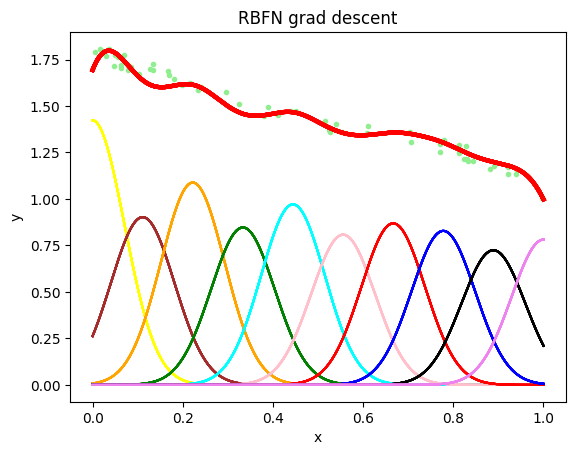

In [20]:
# We use the same batch as before, uncomment if you want to use another batch
# lf = NonLinearLatentFunction()
# size = 500
# batch = lf.get_batch(size)
max_iter = 500
model = GDRBFN(nb_features=10)
start = time.process_time()

for _ in range(max_iter):
    x, y = batch.get_random_sample()
    model.train(x, y, alpha=0.5)

error = model.compute_error(batch.x_data, batch.y_data)
print("error : ", error)
print("RBFN grad descent time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "RBFN grad descent")

#### Recursive Least Squares

Recursive Least Squares is the incremental version of the batch Least Squares method.
In this variant, ${\bf A}$ and ${\bf b}$ are recomputed everytime some new data pair is obtained, with the following equations: 

\begin{align*}
{\bf A}^{(t+1)} &= {\bf A}^{(t)} + \phi({\bf x}^{(t+1)}) \phi({\bf x}^{(t+1)})^\intercal,\\
{\bf b}^{(t+1)} &= {\bf b}^{(t)} + \phi({\bf x}^{(t+1)}) y^{(t+1)}.
\end{align*}

The parameters are then computed as $\mathbf{\theta}^{(t+1)} = {\bf A}^{(t+1)\sharp} b^{(t+1)}$.
One may also use ```numpy.linalg.solve(A,b)``` as before, but this can fail when ${\bf A}$ is singular.

Another incremental approach avoids the computation of the pseudo-inverse ${\bf A}^{(t+1)\sharp}$ 
by computing this inverse incrementally, using the Sherman-Morrison formula: 

\begin{align*}
  u = v^T &= \phi({\bf x}^{(t)}) \\
{\bf A}^{(t+1)\sharp} &= {\bf A}^{(t)\sharp} - \frac{{\bf A}^{(t)\sharp} uv {\bf A}^{(t)\sharp}}{1 + v {\bf A}^{(t)\sharp} u},\\
{\bf b}^{(t+1)} &= {\bf b}^{(t)} + \phi({\bf x}^{(t)}).\\
\end{align*}

**Remark:** to apply this formula, we must start with a non-zero value for $A^{(0)\sharp}$, e.g. the Identity matrix.

In the RLSRBFN class below, fill the code of the `train(self, x, y)` function. 
The one with the Sherman-Morrisson approach is provided.

In [21]:
class RLSRBFN(IncrRBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        self.a = np.zeros(shape=(self.nb_features, self.nb_features))
        self.b = np.zeros(self.nb_features)
        self.a_inv = np.matrix(np.identity(self.nb_features))
    
    # -------- recursive least squares -----------------
    def train(self, x, y):
         
        # To be completed...
        # attention, x s vector and not a matrix,
        # y is a scalar and not a vector
        phi = self.phi_output(x)
        self.a = self.a + np.outer(phi, phi)
        self.b = self.b +  phi.reshape(-1)* y
        self.theta = np.linalg.pinv(self.a) @ self.b

    # -------- recursive least squares with Sherman-Morrison -----------------
    def train_rls_sherman_morrison(self, x, y):
        u = self.phi_output(x)
        v = self.phi_output(x).transpose()
        mat = v * self.a_inv * u

        value = mat[0, 0] + 1
        if value == 0: # If it's not invertible
          print("Non invertible matrix")
          return None
        coef = 1.0 / value

        prod = np.dot(u, v)

        tmp_mat = np.dot(self.a_inv, prod) 
        tmp_mat2 = np.dot(tmp_mat, self.a_inv)

        self.a_inv = self.a_inv - coef * tmp_mat2

        tmp_vec = y * verti_to_horiz(self.phi_output(x))
        self.b = self.b + tmp_vec

        # Very surprisingly, we get a [[1 2 3 4]] vec here instead of [1 2 3 4]
        result = np.dot(self.a_inv, self.b)
        # And even more surprisingly we have to write this so that it works
        self.theta = np.array(result)[0]

Finally, run them:

RLS theta [1.38623822 0.94942927 1.09653693 0.86958227 0.95821839 0.82825377
 0.86851345 0.82431918 0.69818952 0.78189182]
error :  0.2546662522890738
RBFN RLS time: 0.12972800000000007


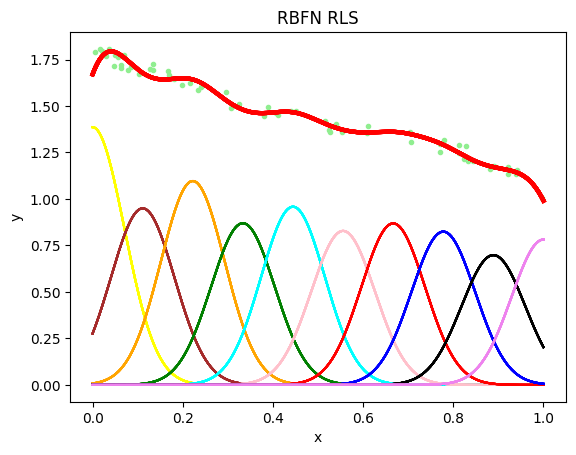

RLS SM theta [1.39143138 0.94509759 1.09564671 0.8691388  0.95726128 0.82721167
 0.86440967 0.82279492 0.70297956 0.77446011]
error :  0.25479083077893616
RBFN  Sherman-Morrisson time: 0.08559400000000039


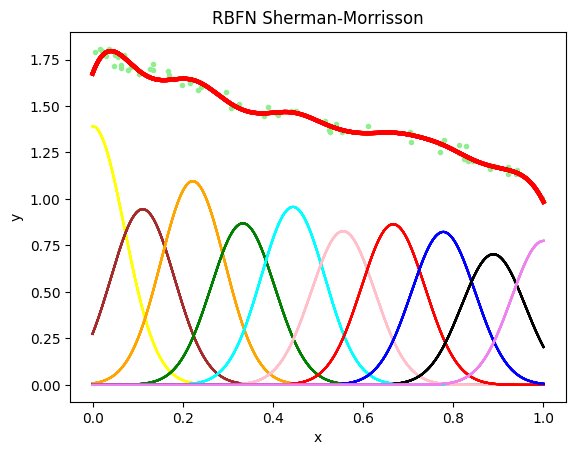

In [22]:
# We use the same batch as before, uncomment if you want to use another batch
# lf = NonLinearLatentFunction()
# size = 500
# batch = lf.get_batch(size)
max_iter = 5000
model = RLSRBFN(nb_features=10)
start = time.process_time()

for _ in range(max_iter):
    x, y = batch.get_random_sample()
    model.train(x, y)

print ("RLS theta", model.theta)
error = model.compute_error(batch.x_data, batch.y_data)
print("error : ", error)
print("RBFN RLS time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "RBFN RLS")

# Need to reinit the model as model.theta must be random again
model = RLSRBFN(nb_features=10)
start = time.process_time()
for _ in range(max_iter):
    x, y = batch.get_random_sample()
    model.train_rls_sherman_morrison(x, y)

print ("RLS SM theta", model.theta)
error = model.compute_error(batch.x_data, batch.y_data)
print("error : ", error)
print("RBFN  Sherman-Morrisson time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "RBFN Sherman-Morrisson")

## Study part: batch RBFNs

 ### Key study: influence of the number of features

Study the evolution of the error as a function of the number of features, from 2 to 60. 
A good idea would be to make a picture with the number of features in the x axis and the residuals in the y axis, 
and then to comment it. Have a look at the model when the number of features is large (e.g. 60). What is happening?


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: divide by zero encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: overflow encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: invalid value encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383

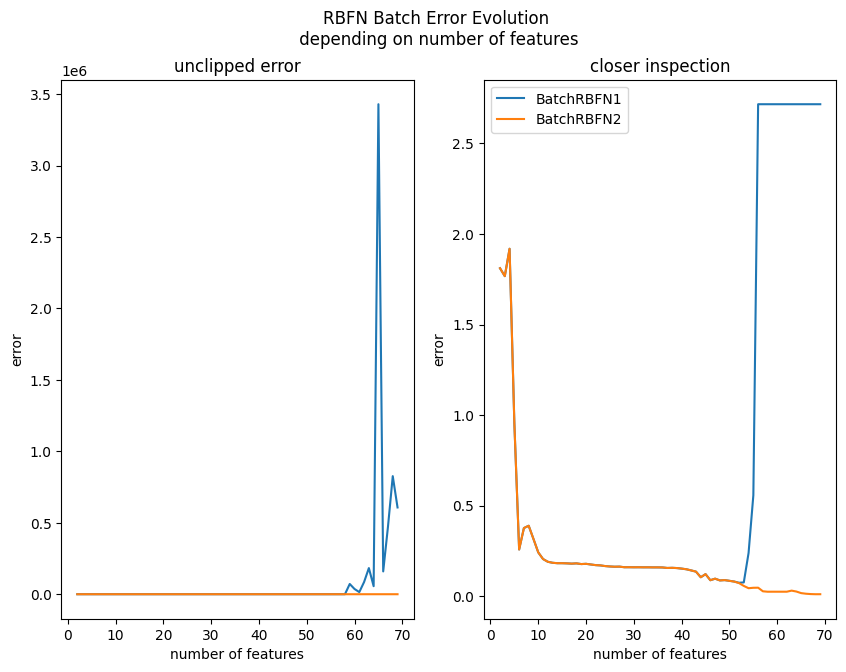

In [23]:
lf = NonLinearLatentFunction()
size = 60
batch = lf.get_batch(size)
nb_features_to_try = np.arange(2,70,1)
errors = {
    "BatchRBFN1" : [],
    "BatchRBFN2" : []
}
for i, nb_features in enumerate(nb_features_to_try):
    model1 = BatchRBFN1(nb_features=nb_features)
    model1.train(batch.x_data, batch.y_data)
    errors["BatchRBFN1"].append(model1.compute_error(batch.x_data, batch.y_data))

    model2 = BatchRBFN2(nb_features=nb_features)
    model2.train(batch.x_data, batch.y_data)
    errors["BatchRBFN2"].append(model2.compute_error(batch.x_data, batch.y_data))

fig, axes = plt.subplots(1,2, figsize=(10,7))
axes = axes.flatten()
for model_name in errors.keys():
    axes[0].plot(nb_features_to_try, errors[model_name], label=model_name)
    axes[0].set_title("unclipped error")
    axes[0].set_ylabel("error")
    axes[0].set_xlabel("number of features")

for model_name in errors.keys():
    axes[1].plot(nb_features_to_try, np.clip(errors[model_name],0,errors[model_name][0]*1.5), label=model_name)
    axes[1].set_title("closer inspection")
    axes[1].set_ylabel("error")
    axes[1].set_xlabel("number of features")
fig.suptitle("RBFN Batch Error Evolution\n depending on number of features")
plt.legend()
plt.show()

We can notice that both `BatchRBFN1` and `BatchRBFN2` exhibit a decreasing error with increasing number of features and optimal error is reached at around 6 features. However, for greater number of features, after around 50, `BatchRBFN1` shows a rapidly increasing error that reaches $3.5 \cdot 10^8$. This is an indicator of a numerical instabilities that are consequences of near-singular matrix inversion with `np.linalg.inv`. This is not observed for `BatchRBFN2` that used pseudo-inverse instead, it is expected since using pseudo-inverse mitigates numerical instabilities.

Indeed, higher number of features increases the dimension of $G^T G$, increasing number of Gaussians relative to number of samples. Indeed, when number of Gaussian features is greater that number of samples, the problem is ill-conditioned and doesn't have a unique solution.

The result of this numeric instability is illustrated on graphs with fitted functions. We can see that weights for Gaussian features have diverged.

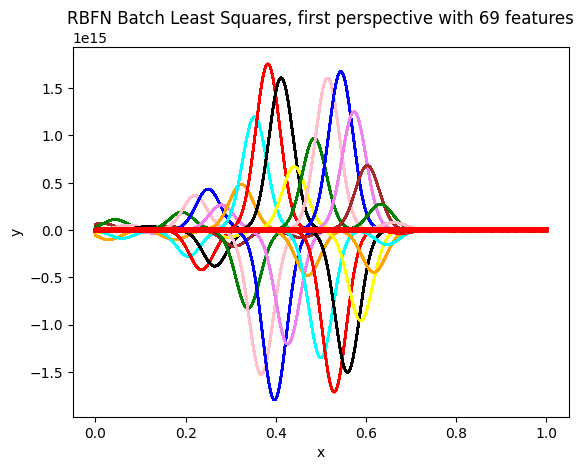

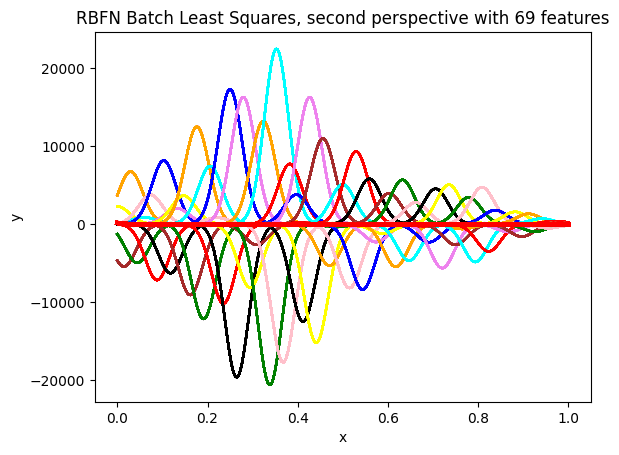

In [24]:
model1.plot(batch.x_data, batch.y_data, f"RBFN Batch Least Squares, first perspective with {nb_features} features")
model2.plot(batch.x_data, batch.y_data, f"RBFN Batch Least Squares, second perspective with {nb_features} features")

### Optional study: comparing both perspectives

Calling the train functions at least 1000 times, comment on the difference in computation time between the first and the second perspective.

In [25]:
lf = NonLinearLatentFunction()
size = 60
batch = lf.get_batch(size)
times = {
    "BatchRBFN1" : [],
    "BatchRBFN2" : []
}
for _ in range(1000):
    model1 = BatchRBFN1(nb_features=nb_features)
    start = time.process_time()
    model1.train(batch.x_data, batch.y_data)
    times["BatchRBFN1"].append(time.process_time() - start)

    model2 = BatchRBFN2(nb_features=nb_features)
    start = time.process_time()
    model2.train(batch.x_data, batch.y_data)
    times["BatchRBFN2"].append(time.process_time() - start)

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: divide by zero encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: overflow encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: invalid value encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: divide by zero encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: overflow encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: invalid value encountered in matmul
  b = G

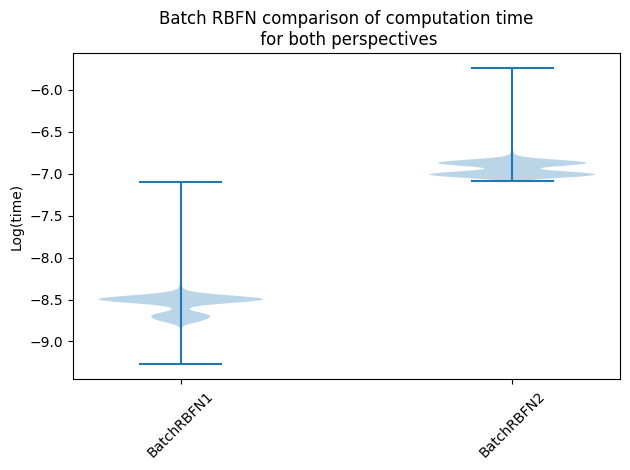

In [26]:
model_names = list(times.keys())
data = [np.log(times[m]) for m in model_names]
# TODO: do a statistical test
plt.violinplot(data, positions=range(1, len(data) + 1))
plt.title("Batch RBFN comparison of computation time\n for both perspectives")
plt.ylabel("Log(time)")
plt.xticks(range(1, len(data) + 1), model_names, rotation=45)
plt.tight_layout()
plt.show()

We can see that `BatchRBFN2` performs slower on average compared to `BatchRBFN1`. It is expected since even though pseudo-inverse is more robust than inverse, it uses SVD which is a heavier operation.



## Study part: incremental RBFNs

### Key study: Incremental versus Batch

By comparing their computation time and error with a growing number of features, 
comment on the main differences between incremental and batch methods with RBFNs. 
What are their main advantages and disadvantages? 
Explain how you would choose between an incremental and a batch method, depending on the context.

In [27]:
lf = NonLinearLatentFunction()
size = 60
batch = lf.get_batch(size)

max_iter = 5000

In [28]:
from copy import deepcopy
nb_features_to_try = np.arange(2,60,1)
errors = {"BatchRBFN1": [],
          "BatchRBFN2": [],
          "GDRBFN": [],
          "RLSRBFN": [],
          "SMRBFN": []
          }
times = deepcopy(errors)
for i, nb_features in enumerate(nb_features_to_try):
    # ------ BatchRBFN1 -----------
    model = BatchRBFN1(nb_features=nb_features)

    start = time.process_time()
    model.train(batch.x_data, batch.y_data)
    errors["BatchRBFN1"].append(model.compute_error(batch.x_data, batch.y_data))
    times["BatchRBFN1"].append(time.process_time() - start)

    # ------ BatchRBFN2 -----------
    model = BatchRBFN2(nb_features=nb_features)
    start = time.process_time()
    model.train(batch.x_data, batch.y_data)
    errors["BatchRBFN2"].append(model.compute_error(batch.x_data, batch.y_data))
    times["BatchRBFN2"].append(time.process_time() - start)

    # ------ GDRBFN -----------

    model = GDRBFN(nb_features=nb_features)
    start = time.process_time()

    for _ in range(max_iter):
        x, y = batch.get_random_sample()
        model.train(x, y, alpha=0.5)

    errors["GDRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
    times["GDRBFN"].append(time.process_time() - start)

    # ------ RLSRBFN -----------

    model = RLSRBFN(nb_features=nb_features)
    start = time.process_time()

    for _ in range(max_iter):
        x, y = batch.get_random_sample()
        model.train(x, y)
    
    errors["RLSRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
    times["RLSRBFN"].append(time.process_time() - start)

    # ------ SMRBFN -----------

    # Need to reinit the model as model.theta must be random again
    model = RLSRBFN(nb_features=nb_features)
    start = time.process_time()
    for _ in range(max_iter):
        x, y = batch.get_random_sample()
        model.train_rls_sherman_morrison(x, y)

    
    errors["SMRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
    times["SMRBFN"].append(time.process_time() - start)


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: divide by zero encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: overflow encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/1612284034.py:10: RuntimeWarning: invalid value encountered in matmul
  self.theta = np.linalg.inv(G.T@G) @ G.T @ y_data
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383

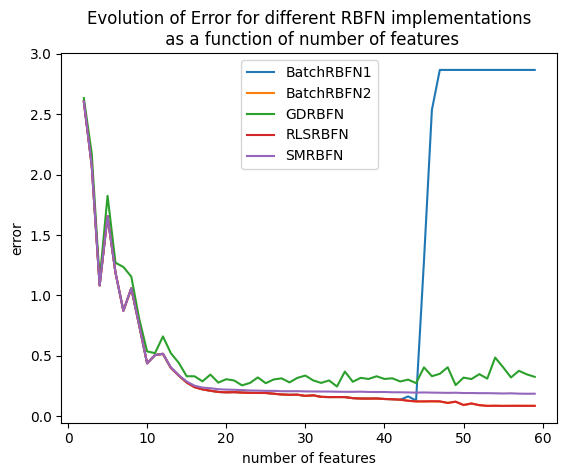

In [29]:
for model_name in errors.keys():
    plt.plot(nb_features_to_try, np.clip(errors[model_name],0,errors[model_name][0]*1.1), label=model_name)
plt.ylabel("error")
plt.xlabel("number of features")
plt.legend()
plt.title("Evolution of Error for different RBFN implementations\n as a function of number of features")
plt.show()

All methods present similar errors before reaching the optimal number of features (around 7 features). After the optimal number of features, `RLSRBFN` and `BatchRBFN2` show identical results. As for previous study sections we can see that `BatchRBFN1` shows numeric instability for a large number of features, which is not the case for `BatchRBFN1` and incremental methods (`GDRBFN`, `RLSRBFN`,`SMRBFN`). `GDRBFN` exhibits rather irregular evolution of error which is coherent with the fact that it only approaches the optimum which is itself instable when problem becomes ill-conditioned. RLSRBFN with Sherman Morrison (`SMRBFN`) exhibits a stable behaviour, but not the same as `RLSRBFN` and `BatchRBFN2`, which is apparently the reflection of how `np.linalg.solve()` and `np.linalg.pinv()` handle ill-conditioned matrices.

We can conclude that the error is the least (and more robust) for `RLSRBFN` (incremental method) and `BatchRBFN2` (batch method).

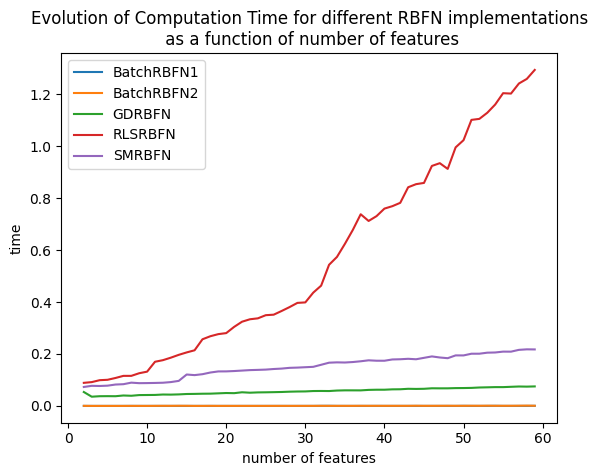

In [30]:
for model_name in errors.keys():
    plt.plot(nb_features_to_try, times[model_name], label=model_name)
plt.ylabel("time")
plt.xlabel("number of features")
plt.title("Evolution of Computation Time for different RBFN implementations\n as a function of number of features")
plt.legend()
plt.show()

Even though `RLSRBFN` exhibits a small training error, it shows a large computation time for larger number of features. 

As a conclusion, we would prefer batch method when we have a fixed dataset, and RLS RBFN with Sherman Morrison in case when we have a stream of the data and we want to be able to continuously update the parameter estimates.

### Optional study 1: comparing recursive variants

By varying the number of features, the number of samples and the amount of noise in the data generator, 
compare the different incremental variants (gradient descent and RLS with and without the Sherman-Morrison formula). 
Which is the most precise? The fastest? Using graphical displays where you are varying the above parameters is strongly encouraged. 
To change the amount of noise in the generated data, 
look in the [latent_function.py](https://github.com/osigaud/regressionLabs/blob/main/regression_labs/latent_function.py) file.


In [31]:
def test_recursive_rbfn(nb_features_to_try, sample_size, sigma):
    lf = NonLinearLatentFunction()
    lf.sigma = sigma
    batch = lf.get_batch(sample_size)
    errors = {"GDRBFN": [],
            "RLSRBFN": [],
            "SMRBFN": []
            }
    times = deepcopy(errors)
    for i, nb_features in enumerate(nb_features_to_try):

        # ------ GDRBFN -----------

        model = GDRBFN(nb_features=nb_features)
        start = time.process_time()

        for _ in range(max_iter):
            x, y = batch.get_random_sample()
            model.train(x, y, alpha=0.5)

        errors["GDRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
        times["GDRBFN"].append(time.process_time() - start)

        # ------ RLSRBFN -----------

        model = RLSRBFN(nb_features=nb_features)
        start = time.process_time()

        for _ in range(max_iter):
            x, y = batch.get_random_sample()
            model.train(x, y)
        
        errors["RLSRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
        times["RLSRBFN"].append(time.process_time() - start)

        # ------ SMRBFN -----------
        
        model = RLSRBFN(nb_features=nb_features)
        start = time.process_time()
        for _ in range(max_iter):
            x, y = batch.get_random_sample()
            model.train_rls_sherman_morrison(x, y)

        
        errors["SMRBFN"].append(model.compute_error(batch.x_data, batch.y_data))
        times["SMRBFN"].append(time.process_time() - start)
    return errors, times

def show_errors_times(errors, times):
    for model_name in errors.keys():
        plt.plot(nb_features_to_try, np.clip(errors[model_name],0,errors[model_name][0]*1.1), label=model_name)
    plt.ylabel("error")
    plt.xlabel("number of features")
    plt.legend()
    plt.title("Evolution of Error for different RBFN implementations\n as a function of number of features")
    plt.show()
    for model_name in errors.keys():
        plt.plot(nb_features_to_try, times[model_name], label=model_name)
    plt.ylabel("time")
    plt.xlabel("number of features")
    plt.title("Evolution of Computation Time for different RBFN implementations\n as a function of number of features")
    plt.legend()
    plt.show()

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/306620300.py:17: RuntimeWarning: divide by zero encountered in matmul
  self.theta = np.linalg.pinv(self.a) @ self.b
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/306620300.py:17: RuntimeWarning: overflow encountered in matmul
  self.theta = np.linalg.pinv(self.a) @ self.b
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/306620300.py:17: RuntimeWarning: invalid value encountered in matmul
  self.theta = np.linalg.pinv(self.a) @ self.b


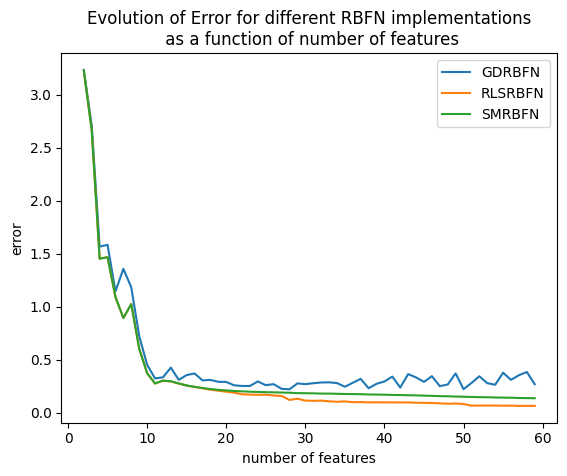

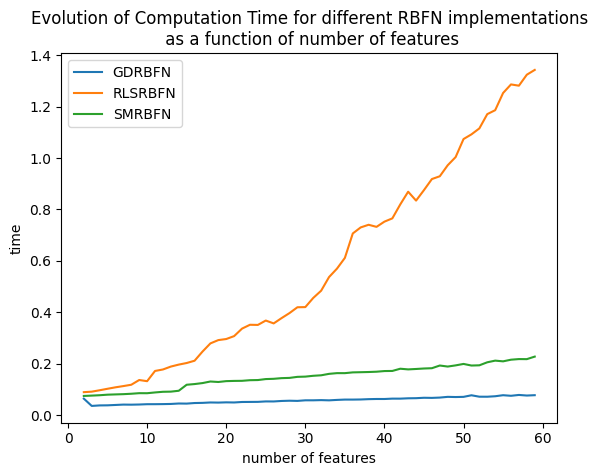

In [32]:
size = 60
sigma=0.1
nb_features_to_try = np.arange(2,60,1)
errors, times = test_recursive_rbfn(nb_features_to_try, size, sigma)
show_errors_times(errors, times)

See interpretation in Key study.

### Optional study 2: Studying overfitting

From the same dataset, generate two batches, a training batch on which your model is trained
and a validation batch which is used to determine when incremental regression starts overfitting
Plot training and validation error curves, and conclude on the right number of iterations to avoid overfitting

# Locally Weighted Regression

Another family of models is Locally Weighted Least Squares (LWLS).
The LWLS algorithm uses a weighted sum of $M$ local linear models.
For each local model $\mathbf{\theta}_k$, the size of the vector $\mathbf{\theta}_k$ 
is the number of dimensions of $\bar{\bf x}$ to take the intercept 
into account (remember that $\bar{\bf x} = ( x_1 \ x_2 \cdots x_d \ 1)^\intercal$ as defined in the provided code 
with the ```bar(x)``` function.
Thus $\dim (\mathbf{\theta}_k) = \dim ({\bf x}) +1 = d + 1$.

The model of the global latent function can be written

$$f({\bf x}) = \sum_{k=1}^{M}  \frac{\phi_k({\bf x}). m_{\mathbf{\theta}_k}({\bf x})}{\sum_{j=1}^{M} \phi_j({\bf x})},$$

with $m_{\mathbf{\theta}_k}({\bf x}) = \bar{\bf x}^\intercal \mathbf{\theta}_k $ and where $M$ is the number of models.

Each local model $\mathbf{\theta}_k$ is optimized by minimizing the following locally weighted error from $N$ datapoints:

$$\epsilon_k(\mathbf{\theta}_k) = \frac{1}{2N}\sum_{i=1}^N \phi_k({\bf x}_i)\left(y_i - m_{\mathbf{\theta}_k}({\bf x}_i)\right)^2$$

$$= \frac{1}{2N}\sum_{i=1}^N \phi_k( {\bf x}_i) \left(y_i- (\bar{\bf x}_i)^\intercal .\mathbf{\theta}_{i} \right)^2.$$

As with the least squares method, we try to cancel out the gradient, which amounts to solving:

$$-\frac{1}{N}\sum_{i=1}^N \phi_k({\bf x}_i)\bar{\bf x}_i \left(y_i - (\bar{\bf x}_i)^\intercal .\mathbf{\theta}_k \right) = 0.$$

Therefore, we pose $\mathbf{\theta}_k = {\bf A}^\sharp_k {\bf b}_k$, with: 
$${\bf A}_k = \sum_{i=1}^N \phi_k({\bf x}_i). \bar{\bf x}_i^\intercal. (\bar{\bf x}_i)$$
$${\bf b}_k = \sum_{i=1}^N \phi_k({\bf x}_i). \bar{\bf x}_i^\intercal. y_i.$$

This calculation gives us the parameters $\mathbf{\theta}_k$ of each local linear model. 
The global parameter $\mathbf{\theta}$ is now a matrix resulting from the concatenation of all local models $\mathbf{\theta}_k$.

## Coding part

The code corresponding to the LWR method is available in the ```LWR``` class below. 

**In this code, you have to fill the ```train(self, x_data, y_data)``` function**

In [382]:
class LWR(Gaussians):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        # The first dimension is 2 because we assume the input is one-dimensional
        # So we just have two parameters per receptive field
        self.theta = np.zeros((2, self.nb_features))

    def f(self, x):
        """
        Get the output of the function approximator for a given vector of datapoints
        :param x: a single vector of N datapoints (each datapoint being of dimension d=1)
        :returns: a vector of N function approximator outputs
        """
        # wval = bar_design(x)
        # phi = self.phi_output(x)
        # linear_model = np.dot(wval, self.theta)
        # val = np.dot(linear_model, phi)
        # numerator = np.sum(val, axis=1)
        # return numerator / np.sum(phi, axis=0)
        weights = self.phi_output(x).T # B x E
        lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
        weighted_sum = (lin_model * weights).sum(-1) # tensor product
        sum_weights = weights.sum(-1)
        return weighted_sum / sum_weights

    def feature(self, x, idx):
        """
         Get the output of the idx^th feature for a given input variable(s)
         :param x: a single or vector of dependent variables with size [d] for which to calculate the features
         :param idx: index of the feature
         :returns: a vector of values
         """
        return np.dot(bar_design(x), self.theta[:, idx])

    # -- compute the residuals --#
    def compute_error(self, x_data, y_data):
      return np.linalg.norm(y_data - self.f(x_data))

    # ----------------------#
    # # Training Algorithm ##
    # ----------------------#

    def train(self, x_data, y_data) -> None:
        """
        Locally weighted least square function
        This code is specific to the 1D case
        :param x_data: a vector of x values
        :param y_data: a vector of y values
        :return: nothing (set the self.theta vector)
        """
        for k in range(self.nb_features):
            A = np.zeros((2, 2))
            b = np.zeros((2, 1))

            nb_points = x_data.shape[0]
            for i in range(nb_points):

                x_i = x_data[i].reshape(1, x_data.shape[1])
                y_i = y_data[i]

                phi = self.phi_output(x_i)

                # To be completed...
                x_i_bar = bar_design(x_i)
                A += phi[k] * (x_i_bar.T @ x_i_bar)
                b += phi[k] * (x_i_bar.T * y_i)

            result = np.dot(np.linalg.pinv(A), b)
            for i in range(2):
                self.theta[i, k] = result[i, 0]


    def plot(self, x_data, y_data, title):
        xs = np.linspace(0.0, 1.0, 1000)
        z = []
        for i in xs:
            val = self.f(np.array([[i]]))
            z.append(val)


        plt.plot(x_data, y_data, 'o', markersize=3, color='lightgreen')
        plt.plot(xs, z, lw=2, color='red')
        for i in range(self.nb_features):
            ww = (1.0 - 0.0) / self.nb_features / 2.
            xstmp = np.linspace(self.centers[i] - ww, self.centers[i] + ww, 100)

            z2 = []
            for j in xstmp:
                z2.append(self.feature(np.array([[j]]), i))
            plt.plot(xstmp, z2, lw=2, color='blue', ls='-')
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()

Once this is done, you can run the code:

LWR time: 0.005890999999792257


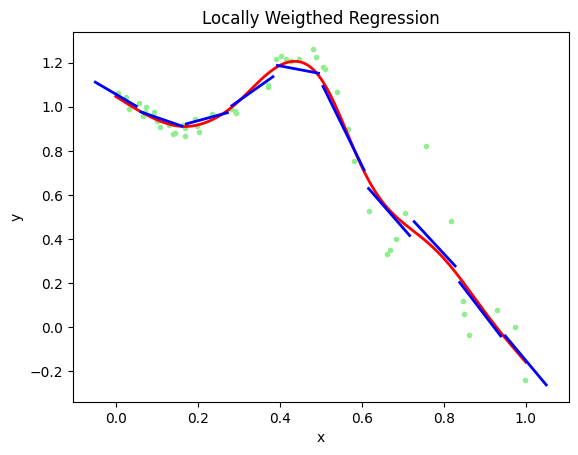

In [380]:
lf = NonLinearLatentFunction()
size = 50
batch = lf.get_batch(size)
model = LWR(nb_features=10)

start = time.process_time()
model.train(batch.x_data, batch.y_data)
print("LWR time:", time.process_time() - start)
model.plot(batch.x_data, batch.y_data, "Locally Weigthed Regression")

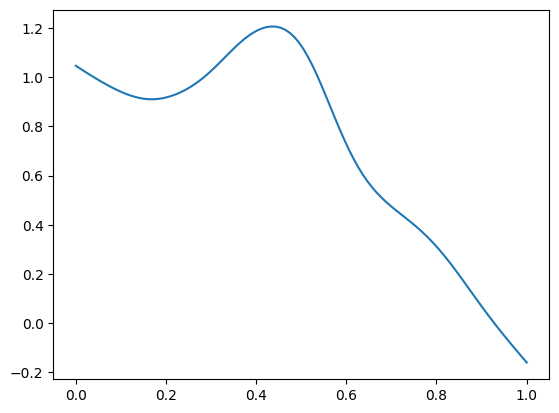

In [381]:
x = np.linspace(0,1,100).reshape((-1,1))
y = model.f(x)
plt.plot(x,y)

## Study part: LWR

### Key study: impact of the number of features

Study the impact of the number of features on the accuracy of LWR: make a drawing where you measure 
the residuals as a function of the number of features.

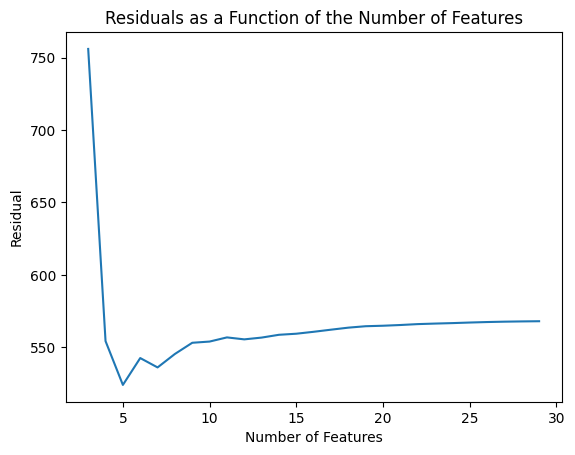

In [35]:
nb_features_range = np.arange(3, 30)
residuals = []
for nb_features in nb_features_range:
    model = LWR(nb_features=nb_features)
    model.train(batch.x_data, batch.y_data)
    residuals.append(model.compute_error(batch.x_data, batch.y_data))

plt.title("Residuals as a Function of the Number of Features")
plt.plot(nb_features_range, residuals)
plt.xlabel("Number of Features")
plt.ylabel("Residual")
plt.show()

We see that as the number of features increases initially improves the performance of the LWR model (reducing the residual). However pas a certain point increasing the number of features steadily increases the residual. 

The reason for this is that as the number of features increases past a certain point, each feature starts "looking" only at a very small amount of points close to it so the slope becomes very specific to the few points around and is more sensitive to noise. As a result it and does not match well with the general shape of the function.



### Optional study: regions with missing data

Introduce a filter that removes part of the data in some region of the x axis. Study how LWR behaves in regions where data is sparse.
the residuals as a function of the number of features.

LWR time: 0.03602700000000425


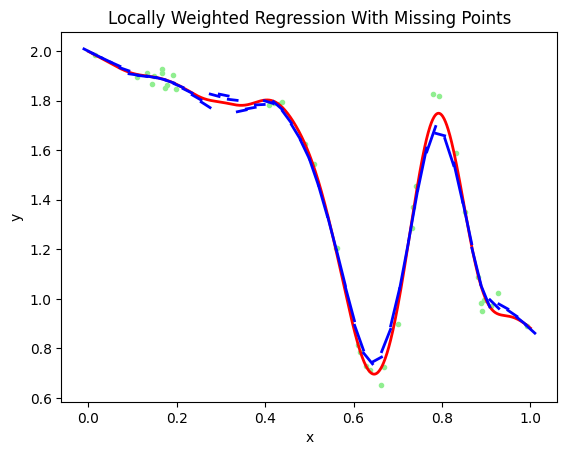

In [36]:
x = batch.x_data
y = batch.y_data

mask = (x[:, 0] < 0.2) | (x[:, 0] > 0.4)

x_filtered = x[mask]
y_filtered = y[mask]

model = LWR(nb_features=50)

start = time.process_time()
model.train(x_filtered, y_filtered)
print("LWR time:", time.process_time() - start)

model.plot(
    x_filtered,
    y_filtered,
    "Locally Weighted Regression With Missing Points",
)

The model behaves quite linearly in the area with the missing data.

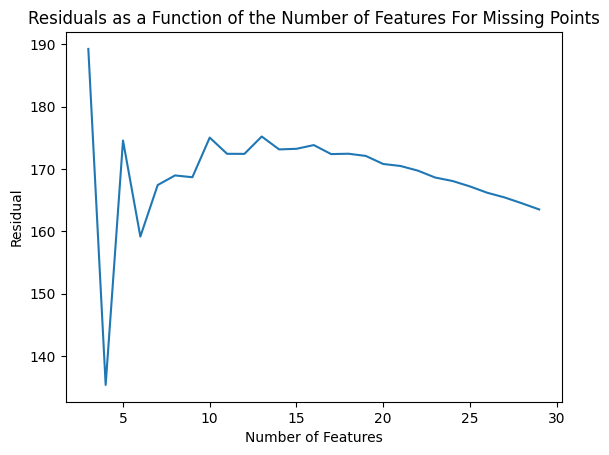

In [35]:
nb_features_range = np.arange(3, 30)
residuals = []
for nb_features in nb_features_range:
    model = LWR(nb_features=nb_features)
    model.train(x_filtered, y_filtered)
    residuals.append(model.compute_error(x_filtered, y_filtered))

plt.title("Residuals as a Function of the Number of Features For Missing Points")
plt.plot(nb_features_range, residuals)
plt.xlabel("Number of Features")
plt.ylabel("Residual")
plt.show()

The residuals as a function of the number of features seems to be about the same as without the missing features.

# Regression with Neural Networks (in pytorch)

In this part we perform regression with neural networks.
We are using pytorch, which does for you a lot of what you have to code when using gradient descent with RBFNs.

All the code for performing regression is provided, you can focus on the study part.
The study below will focus on different training regimes.

In [37]:
# !pip install torch

import torch as th
from torch import nn
from torch.nn import functional as func
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

We use pytorch Dataset and DataLoader classes to facilitate data processing

In [38]:
class NonLinearRegressionData(Dataset):
    """
    Custom 'Dataset' object for our regression data.
    Must implement these functions: __init__, __len__, and __getitem__.
    """

    def __init__(self, x_data, y_data):
        self.x_data = th.from_numpy(x_data).float()
        self.y_data = th.from_numpy(y_data).float()

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return (self.x_data[idx], self.y_data[idx])

Now, we define a neural network model.
It has the same $f()$ function as previous models, and the ```compute_error(x,y)``` function is also the same.
But now, the training function just calls ```update(loss)``` and gradient descent is performed using pytorch functions.

In [40]:
##################################################
## set up a multi-layer perceptron with PyTorch
##################################################


class NeuralNetwork(nn.Module):
    def __init__(self, l1, l2, l3, l4, out, learning_rate):
        super(NeuralNetwork, self).__init__()
        self.sigmoid = nn.Sigmoid()  # not used in the default version
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(l1, l2)
        self.fc2 = nn.Linear(l2, l3)
        self.fc3 = nn.Linear(l3, l4)
        self.fc4 = nn.Linear(l4, out)
        self.optimizer = th.optim.Adam(
            self.parameters(), lr=learning_rate
        )  # Here we could use different optimizers

    def forward(self, x):
        # x is assumed to be a tensor
        hidden1 = self.relu(self.fc1(x))
        hidden2 = self.relu(self.fc2(hidden1))
        hidden3 = self.relu(self.fc3(hidden2))
        output = self.fc4(hidden3)
        return output

    def compute_error(self, x_data, y_data):
        """
        Compute the residual error
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint
        :return: the total residual error
        """
        x = th.from_numpy(x_data).float()
        return np.linalg.norm(y_data - self.forward(x).detach().squeeze().numpy())

    def update(self, loss, retain_graph=False) -> None:
        """
        Apply a loss to a network using gradient backpropagation
        :param loss: the applied loss
        :return: nothing
        """
        self.optimizer.zero_grad()
        loss.backward(retain_graph=retain_graph)
        self.optimizer.step()

    def plot(self, x_data, y_data, title):
        """
        Given a dataset x_data, y_data, plots the points of the dataset (in green),
        and the resulting model of the latent function (in red)
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint
        :param title: a title for the figure
        :return: nothing
        """

        plt.plot(x_data, y_data, "o", markersize=3, color="lightgreen")

        inputs = th.from_numpy(x_data).float()
        formatted_input = th.reshape(inputs, (len(inputs), 1))
        y_model = model.forward(formatted_input).detach().squeeze().numpy()

        plt.plot(x_data, y_model, "o", markersize=4, color="red")

        size = 500
        xs = np.linspace(0.0, 1.0, size)
        txs = th.from_numpy(xs).float()
        ftxs = th.reshape(txs, (len(txs), 1))
        ys = model.forward(ftxs).detach().squeeze().numpy()
        plt.plot(xs, ys, lw=1, color="pink")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()

### General data set-up

We store data into a pytorch dataset

In [44]:
# We use a non-linear batch of size 100
lf = NonLinearLatentFunction()
size = 100
batch = lf.get_batch(size)

# instantiate Dataset object for current training data
train_data = NonLinearRegressionData(batch.x_data, batch.y_data)

### Training loop

In [87]:
def train(max_iter, freq, train_dataloader, verbose=True):
    current_loss = 0.0

    # Iterate for a number of training iterations
    for epoch in range(max_iter):
        # Iterate over the DataLoader for training data
        for _, data in enumerate(train_dataloader, 0):
            # Get inputs
            inputs, targets = data
            formatted_input = th.reshape(inputs, (len(inputs), 1))
            outputs = model(formatted_input).squeeze()
            # Compute loss
            loss = func.mse_loss(outputs, targets)
            # Perform optimization
            model.update(loss)
            # Print statistics
            current_loss += loss.item()

        if (epoch + 1) % freq == 0 and verbose:
            print("Loss after iteration %5d: %.3f" % (epoch + 1, current_loss))
            current_loss = 0.0

### Batch, iterative version

We first train the network with a single batch of data.
We perform max_iter iterations to improve the network.

nb iterations 5000
Loss after iteration   250: 17.735
Loss after iteration   500: 10.352
Loss after iteration   750: 5.298
Loss after iteration  1000: 2.466
Loss after iteration  1250: 1.959
Loss after iteration  1500: 1.653
Loss after iteration  1750: 0.712
Loss after iteration  2000: 0.204
Loss after iteration  2250: 0.203
Loss after iteration  2500: 0.203
Loss after iteration  2750: 0.203
Loss after iteration  3000: 0.201
Loss after iteration  3250: 0.202
Loss after iteration  3500: 0.201
Loss after iteration  3750: 0.201
Loss after iteration  4000: 0.200
Loss after iteration  4250: 0.199
Loss after iteration  4500: 0.200
Loss after iteration  4750: 0.200
Loss after iteration  5000: 0.199
Batch training time: 1.968303000000006
Global batch error: 0.27821272963575544


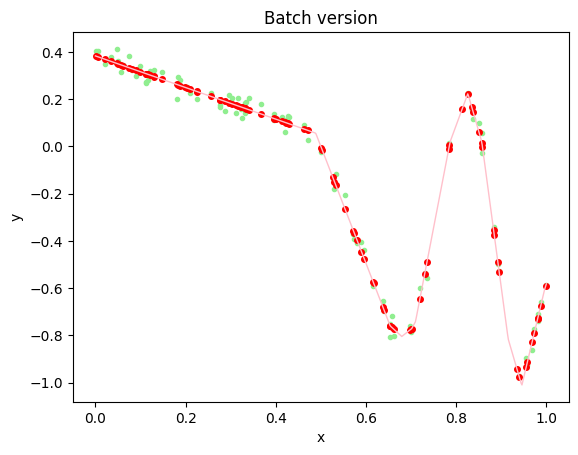

In [47]:
# Instantiate DataLoader
# We get a full size batch and shuffle the data
train_dataloader = DataLoader(train_data, batch_size=size, shuffle=True)

model = NeuralNetwork(1, 10, 10, 10, 1, learning_rate=3e-3)

max_iter = 5000
print("nb iterations", max_iter)

start = time.process_time()
train(max_iter, 250, train_dataloader)

print("Batch training time:", time.process_time() - start)
error = model.compute_error(batch.x_data, batch.y_data)
print("Global batch error:", error)
model.plot(batch.x_data, batch.y_data, "Batch version")

### Incremental version using minibatches

For getting minibatches, see the [get_minibatch()](https://github.com/osigaud/regressionLabs/blob/main/regression_labs/batch.py) function.

nb iterations 5000
Loss after iteration   250: 69.454
Loss after iteration   500: 51.384
Loss after iteration   750: 50.105
Loss after iteration  1000: 49.769
Loss after iteration  1250: 49.687
Loss after iteration  1500: 49.695
Loss after iteration  1750: 49.704
Loss after iteration  2000: 49.693
Loss after iteration  2250: 47.989
Loss after iteration  2500: 33.933
Loss after iteration  2750: 9.895
Loss after iteration  3000: 5.956
Loss after iteration  3250: 5.368
Loss after iteration  3500: 4.831
Loss after iteration  3750: 4.316
Loss after iteration  4000: 3.842
Loss after iteration  4250: 3.385
Loss after iteration  4500: 2.971
Loss after iteration  4750: 2.544
Loss after iteration  5000: 2.212
Incremental mini-batch training time: 4.891002999999998
Global batch error: 0.44285202045102107


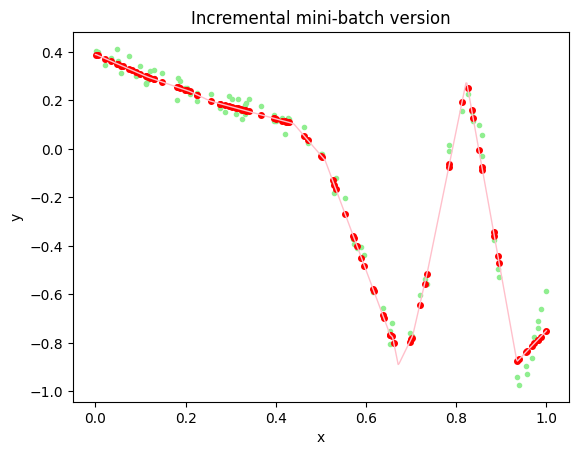

In [49]:
# Instantiate DataLoader
# We get mini_batches of size 25 and shuffle the data
train_dataloader = DataLoader(train_data, batch_size=25, shuffle=True)
model = NeuralNetwork(1, 10, 10, 10, 1, learning_rate=1e-3)

max_iter = 5000
print("nb iterations", max_iter)

start = time.process_time()
train(max_iter, 250, train_dataloader)
print("Incremental mini-batch training time:", time.process_time() - start)
error = model.compute_error(batch.x_data, batch.y_data)
print("Global batch error:", error)
model.plot(batch.x_data, batch.y_data, "Incremental mini-batch version")

You can see that the batch version is a special case of the mini-batch version
where the size of the mini-batch is the size of the batch.

## Study part: neural networks

### Key study: comparisons between versions

Play with the dataset size. Once you have properly tuned the variants (hyperparameters), study the evolution of the final error
and the training time depending on the size of the minibatch for a given budget of iterations.

In [50]:
# This key study is expected for the lab

# To be completed...

lf = NonLinearLatentFunction()
n_sizes = 3
sizes = [30, 90, 270]
batches = [lf.get_batch(size) for size in sizes]
train_datas = [NonLinearRegressionData(batch.x_data, batch.y_data) for batch in batches]

Number of iterations: 5000
Loss after iteration  1000: 78.148
Loss after iteration  2000: 12.075
Loss after iteration  3000: 12.160
Loss after iteration  4000: 11.744
Loss after iteration  5000: 11.802
Batch training time: 2.4035790000000077
Global batch error: 0.4055162539912051


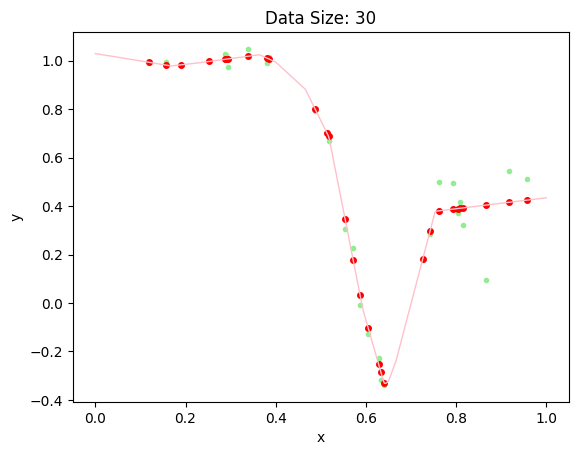

Number of iterations: 5000
Loss after iteration  1000: 199.438
Loss after iteration  2000: 31.847
Loss after iteration  3000: 29.468
Loss after iteration  4000: 29.134
Loss after iteration  5000: 28.574
Batch training time: 4.7612570000000005
Global batch error: 0.7819807257497838


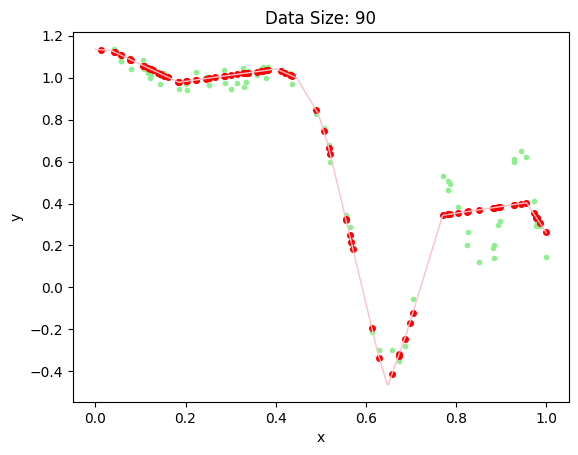

Number of iterations: 5000
Loss after iteration  1000: 130.527
Loss after iteration  2000: 76.878
Loss after iteration  3000: 74.799
Loss after iteration  4000: 72.848
Loss after iteration  5000: 71.458
Batch training time: 13.683941000000004
Global batch error: 1.2831677284637166


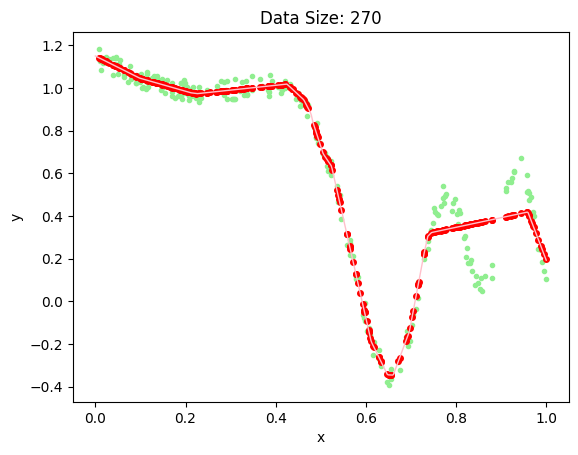

In [51]:
for i in range(n_sizes):
    train_dataloader = DataLoader(train_datas[i], batch_size=25, shuffle=True)

    model = NeuralNetwork(1, 10, 10, 10, 1, learning_rate=3e-3)

    max_iter = 5000
    print(f"Number of iterations: {max_iter}")

    start = time.process_time()
    train(max_iter, 1000, train_dataloader)
    print(f"Batch training time: {time.process_time() - start}")
    error = model.compute_error(batches[i].x_data, batches[i].y_data)
    print(f"Global batch error: {error}")
    model.plot(batches[i].x_data, batches[i].y_data, f"Data Size: {sizes[i]}")

The global batch error seems to increase as the data size increases, although visually the fit seems better for higher data set sizes.

For consistency we will use the same data for all the neural networks with different hyperparameters.

In [52]:
size = 100  # Also I a parameter but in order to keep the same data for all the models I will not change it
lf = NonLinearLatentFunction()
batch = lf.get_batch(size)
train_data = NonLinearRegressionData(batch.x_data, batch.y_data)

We create a function that takes in hyperparameters and computes the average error and average training time for a neural network with these hyperparameters over `n_seeds=5` seeds.

In [54]:
def compute_average_error(hyperparameters, n_seeds=5, verbose=False):
    average_error = 0
    average_training_time = 0

    for seed in range(n_seeds):
        th.manual_seed(seed)

        # Tuneable hyperparameters
        hidden_layers = hyperparameters["hidden_layers"]
        learning_rate = hyperparameters["learning_rate"]
        max_iter = hyperparameters["max_iter"]
        minibatch_size = hyperparameters["minibatch_size"]

        train_dataloader = DataLoader(
            train_data, batch_size=minibatch_size, shuffle=False
        )

        model = NeuralNetwork(
            1, hidden_layers[0], hidden_layers[1], hidden_layers[2], 1, learning_rate
        )

        # Training part
        start = time.process_time()
        train(max_iter, 500, train_dataloader, verbose=verbose)
        training_time = time.process_time() - start
        if verbose:
            print(f"Training time: {training_time}")
        error = model.compute_error(batch.x_data, batch.y_data)
        if verbose:
            print(f"Error: {error}")

        average_error += error
        average_training_time += training_time

        if verbose:
            model.plot(batch.x_data, batch.y_data, "Model")

    average_error /= n_seeds
    average_training_time /= n_seeds

    return average_error, average_training_time

In [55]:
hyperparameters = {
    "hidden_layers": (10, 10, 10),
    "learning_rate": 3e-3,
    "max_iter": 500,
    "minibatch_size": 25,
}

compute_average_error(hyperparameters)

(np.float64(14.860471201138818), 0.49564639999999827)

We can run this function over different hyperparameters.

In [56]:
logs = []
for hidden_layers in [(10, 10, 10), (5, 10, 15), (15, 10, 5)]:
    for learning_rate in [3e-3, 1e-2, 1e-4]:
        for max_iter in [500, 1000, 3000]:
            for minibatch_size in [25, 100, max_iter]:
                hyperparameters = {
                    "hidden_layers": hidden_layers,
                    "learning_rate": learning_rate,
                    "max_iter": max_iter,
                    "minibatch_size": minibatch_size,
                }
                logs.append((hyperparameters, compute_average_error(hyperparameters)))
                # print("Done!")

We can see the logs here.

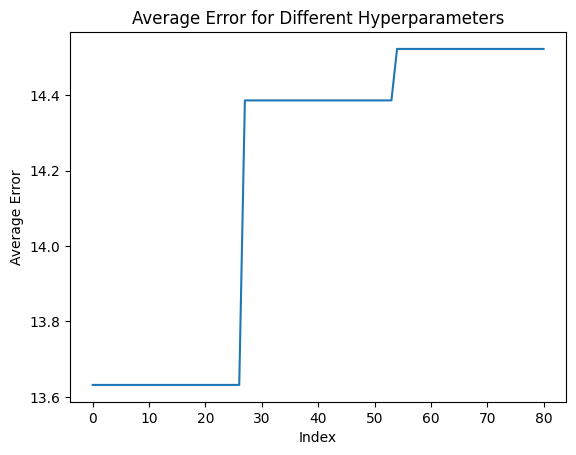

In [49]:
plt.title("Average Error for Different Hyperparameters")
plt.plot(np.array([log[1][0] for log in logs]))
plt.xlabel("Index")
plt.ylabel("Average Error")
plt.show()

We see in this pretty bad graph above that the average error is quite similar for all the models. The three steps correspond to the different model architectures (10, 10, 10), (5, 10, 15) and (15, 10, 5). It seems that no matter the hyperparameters in all our cases we converge to the same optimums giving us averages.

It is hard to give an explanation to why (10, 10, 10) has the lowest average error. It could be a fluke due to the small number of samples for the average `nb_seeds=5`.

What we find is that all the models seem to perform about the same. So we will just use the one that was given in the exercise. Let's now study how the size of the minibatch size affects the time and size of the error.

In [57]:
minibatch_sizes = [10 * i for i in range(1, 11)]
average_errors = []
average_times = []
for minibatch_size in minibatch_sizes:
    hyperparameters = {
        "hidden_layers": (10, 10, 10),
        "learning_rate": 3e-3,
        "max_iter": 3000,
        "minibatch_size": minibatch_size,
    }
    average_error, average_time = compute_average_error(hyperparameters, verbose=False)
    average_errors.append(average_error)
    average_times.append(average_time)
    print("Done!")


Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!


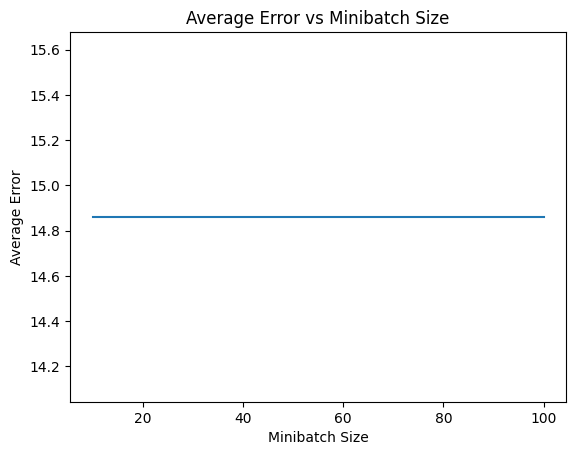

In [58]:
plt.title("Average Error vs Minibatch Size")
plt.plot(minibatch_sizes, average_errors)
plt.xlabel("Minibatch Size")
plt.ylabel("Average Error")
plt.show()

We see that in our case here the average error is the same. This indicates that all our models are converging to the same optimums. Since we would expect mini batch to only impact the rate of convergence this is expected and means that our `max_iter` is large enough for the trainings to converge for all the models.

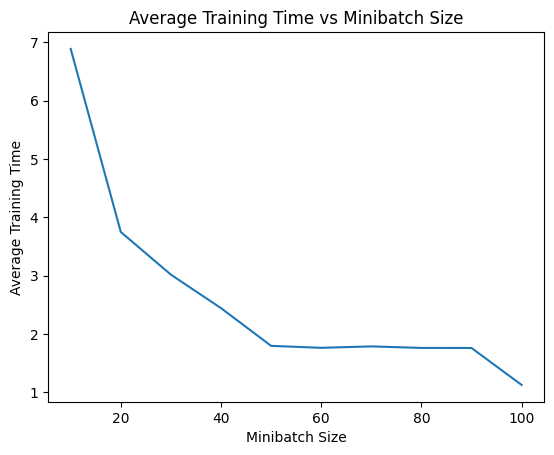

In [59]:
plt.title("Average Training Time vs Minibatch Size")
plt.plot(minibatch_sizes, average_times)
plt.xlabel("Minibatch Size")
plt.ylabel("Average Training Time")
plt.show()

We see that the average training time is reduced when the minibatch. This is logical as a smaller minibatch size means a greater number parameter updates per epoch, so with the same number of iterations it will do more parameter updates. However it should converge faster and therefore reduce the number of epochs required to converge. In our case we are fixing the number of epochs (`max_iter`) so this is not seen.

### Optional study 1: preventing overfitting

Distinguish training, validation and test batches, train the network until the validation loss stops decreasing, 
count the number of training epochs and measure the loss on the test batch.
By running a number of training epochs smaller and larger than the one found with the validation loss approach, 
study if this approach truly prevents overfitting. Showing the training loss and validation loss curves is higly recommended.

### Optional study 2: impact of the network architecture

Vary the activation functions, the number of layers and the number of neurons per layer and study the impact on regression error.

# Global study part: comparing the families of methods

### Optional study 1: Batch RBFNs versus LWR

By using the same batches of data and tuning your models depending on these batches, compare the performance
and training time of batch RBFNs and LWR under various training regimes. Change the amount of noise, the quantity of data,
or study the impact of missing data.

### Optional study 2: Incremental RBFNs versus neural networks

By using the same batches of data and tuning your models depending on these batches, compare the performance
and training time of incremental RBFNs and neural networks under various training regimes.
 Change the amount of noise, the quantity of data, or study the impact of missing data.

# Report

In [383]:
import random
import os
from tqdm.auto import trange, tqdm
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    th.manual_seed(seed)           # CPU
    th.cuda.manual_seed(seed)      # Current GPU
    th.cuda.manual_seed_all(seed)  # All GPUs
    th.backends.cudnn.deterministic = True
    th.backends.cudnn.benchmark = False


Models: RBFN, LWR, ANN

In [384]:
rbfn = BatchRBFN2(nb_features=15)

lwr = LWR(nb_features=5)

ann = NeuralNetwork(l1=1, l2=10, l3=10,l4=10, out=1, learning_rate=3e-3)
max_iter = 1000
batch_size = None

In [385]:
set_all_seeds(123)
sizes = (100, 1000, 5000)
sigmas = (0.01, 0.1, 0.5) 
nb_experiments = 10
errors = {"RBFN":np.zeros((3,3,nb_experiments)),
           "LWR": np.zeros((3,3,nb_experiments)), 
           "ANN": np.zeros((3,3,nb_experiments))}
times = deepcopy(errors)
for k in trange(nb_experiments):
    # initiate new function for each new experiment!
    lf = NonLinearLatentFunction()
    for i, size in enumerate(sizes):
        for j, sigma in enumerate(sigmas):

            # Get the data:
            lf.sigma = sigma
            batch = lf.get_batch(size)
            # specifically for ANN:
            train_data = NonLinearRegressionData(batch.x_data, batch.y_data)
            train_dataloader = DataLoader(train_data, 
                                        batch_size=size if batch_size is None else batch_size, 
                                        shuffle=True)

            # ------------- RBFN -------------
            start = time.process_time()
            rbfn.train(batch.x_data, batch.y_data)
            errors["RBFN"][i,j,k] = rbfn.compute_error(batch.x_data, batch.y_data)
            times["RBFN"][i,j, k] = time.process_time() - start

            # ------------- LWR -------------

            start = time.process_time()
            lwr.train(batch.x_data, batch.y_data)
            errors["LWR"][i,j, k] = lwr.compute_error(batch.x_data, batch.y_data)
            times["LWR"][i,j,k] = time.process_time() - start

            # ------------- ANN -------------

            start = time.process_time()
            model = ann #NOTE: `train()`` takes global `model` variable   
            train(max_iter, 250, train_dataloader) # TODO: 2nd arg?
            errors["ANN"][i,j,k] = model.compute_error(batch.x_data, batch.y_data)
            times["ANN"][i,j,k] = time.process_time() - start

            print(i,j)

            # plt.plot(batch.x_data, batch.y_data, ".")
            # plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: divide by zero encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: overflow encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/3728133934.py:14: RuntimeWarning: invalid value encountered in matmul
  b = G.T @ y_data
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


Loss after iteration   250: 69.062
Loss after iteration   500: 1.846
Loss after iteration   750: 1.379
Loss after iteration  1000: 1.306
0 0
Loss after iteration   250: 1.681
Loss after iteration   500: 1.507
Loss after iteration   750: 1.309
Loss after iteration  1000: 1.136
0 1
Loss after iteration   250: 5.800
Loss after iteration   500: 5.407
Loss after iteration   750: 5.348
Loss after iteration  1000: 5.326
0 2


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/2286368516.py:21: RuntimeWarning: divide by zero encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/2286368516.py:21: RuntimeWarning: overflow encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46459/2286368516.py:21: RuntimeWarning: invalid value encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E


Loss after iteration   250: 0.985
Loss after iteration   500: 0.559
Loss after iteration   750: 0.539
Loss after iteration  1000: 0.518
1 0
Loss after iteration   250: 0.708
Loss after iteration   500: 0.680
Loss after iteration   750: 0.665
Loss after iteration  1000: 0.649
1 1
Loss after iteration   250: 5.672
Loss after iteration   500: 5.339
Loss after iteration   750: 5.160
Loss after iteration  1000: 5.042
1 2
Loss after iteration   250: 0.375
Loss after iteration   500: 0.032
Loss after iteration   750: 0.027
Loss after iteration  1000: 0.025
2 0
Loss after iteration   250: 0.240
Loss after iteration   500: 0.229
Loss after iteration   750: 0.229
Loss after iteration  1000: 0.229
2 1
Loss after iteration   250: 5.503
Loss after iteration   500: 5.285
Loss after iteration   750: 5.285
Loss after iteration  1000: 5.284
2 2
Loss after iteration   250: 13.218
Loss after iteration   500: 6.403
Loss after iteration   750: 5.137
Loss after iteration  1000: 2.740
0 0
Loss after iteratio

In [386]:
print(errors)
print(times)

{'RBFN': array([[[ 0.10199065,  0.25343561,  0.40978051,  0.16926932,
          0.14120805,  0.23735624,  0.05094148,  0.08392443,
          0.04190679,  0.25008969],
        [ 0.28929421,  0.64637514,  0.59950125,  0.29922164,
          0.30761072,  0.40424361,  0.29976046,  0.28626191,
          0.2739545 ,  0.35510769],
        [ 1.36488749,  1.39347167,  1.48557255,  1.34530044,
          1.33341079,  1.26987296,  1.23437814,  1.32926714,
          1.34776046,  1.41918013]],

       [[ 0.31592899,  1.40750577,  1.75476991,  0.49852309,
          0.50900692,  0.79716556,  0.17638504,  0.298317  ,
          0.27010935,  0.6924075 ],
        [ 0.95028762,  1.49249245,  1.99844334,  1.09084647,
          0.9954111 ,  1.23049008,  0.90960366,  0.92741192,
          0.93761702,  1.18246793],
        [ 4.44704409,  4.77018056,  4.87127244,  4.65803935,
          4.50245647,  4.671034  ,  4.40264315,  4.45643139,
          4.46570036,  4.56297629]],

       [[ 0.74366289,  3.29355322,  3.9

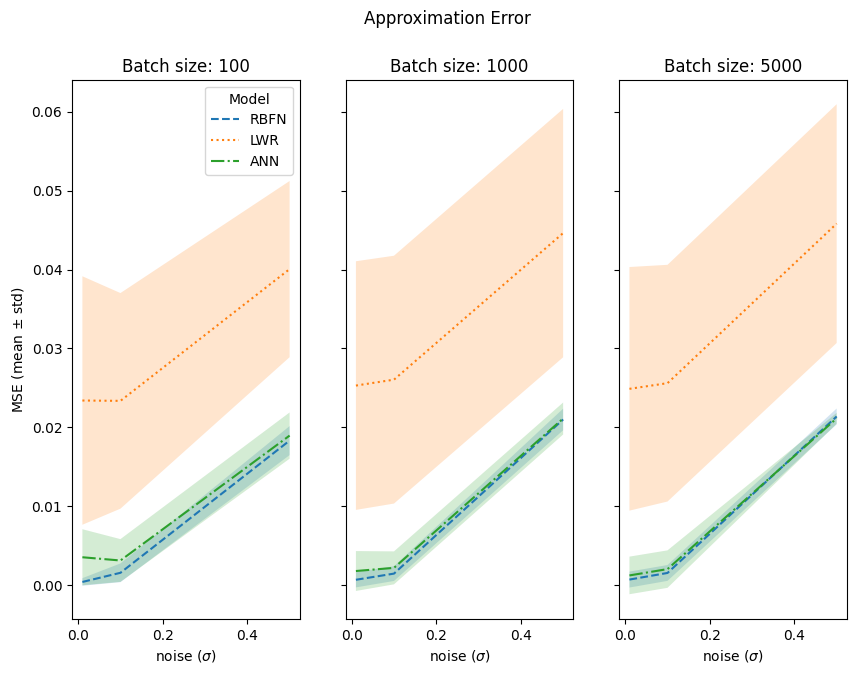

In [387]:
linestyles = ("--", ":", "-.")
model_names = ['RBFN', 'LWR', 'ANN']

fig, axes = plt.subplots(1,3, sharey = True, figsize=(10,7))
axes[0].set_ylabel("MSE (mean $\\pm$ std)")
axes = axes.flatten()

for i, size in enumerate(sizes): 
    for m, model_name in enumerate(model_names):
        mses = (errors[model_name][i,:,:]**2)/size
        mean = mses.mean(-1)
        std = mses.std(-1)
        axes[i].set_title("Batch size: "+str(size))
        axes[i].plot(sigmas, mean, label=model_name, linestyle=linestyles[m])
        axes[i].fill_between(sigmas, mean-std, mean+std, alpha = 0.2)
        axes[i].set_xlabel("noise ($\\sigma$)")
axes[0].legend(title="Model")
fig.suptitle("Approximation Error")
plt.show()

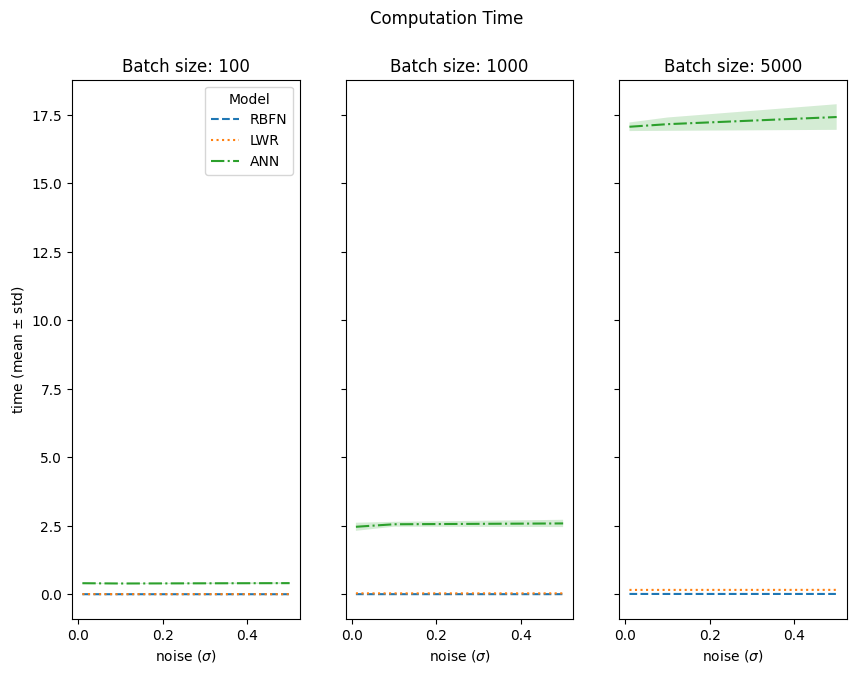

In [394]:
linestyles = ("--", ":", "-.")
model_names = ['RBFN', 'LWR', "ANN"] # ['RBFN', 'LWR', 'ANN']

fig, axes = plt.subplots(1,3, sharey = True, figsize=(10,7))
axes[0].set_ylabel("time (mean $\\pm$ std)")
axes = axes.flatten()

for i, size in enumerate(sizes): 
    for m, model_name in enumerate(model_names):
        mean = times[model_name][i,:,:].mean(-1)
        std = times[model_name][i,:,:].std(-1)
        axes[i].set_title("Batch size: "+str(size))
        axes[i].plot(sigmas, mean, label=model_name, linestyle=linestyles[m])
        axes[i].fill_between(sigmas, mean-std, mean+std, alpha = 0.2)
        axes[i].set_xlabel("noise ($\\sigma$)")
axes[0].legend(title="Model")
fig.suptitle("Computation Time")
plt.show()

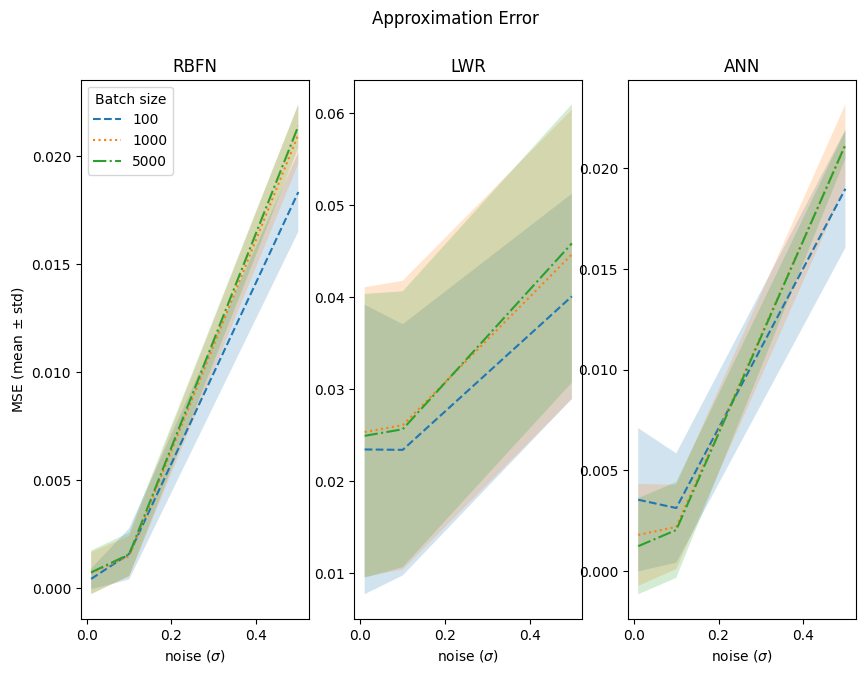

In [389]:
linestyles = ("--", ":", "-.")
model_names = ['RBFN', 'LWR', 'ANN']

fig, axes = plt.subplots(1,3, sharey = False, figsize=(10,7))
axes[0].set_ylabel("MSE (mean $\\pm$ std)")
axes = axes.flatten()

for m, model_name in enumerate(model_names):
    for i, size in enumerate(sizes): 
        mses = (errors[model_name][i,:, :]**2)/size
        mean = mses.mean(-1)
        std = mses.std(-1)
        axes[m].set_title(model_name)
        axes[m].plot(sigmas, mean, label=str(size), linestyle=linestyles[i])
        axes[m].fill_between(sigmas, mean-std, mean+std, alpha = 0.2)
        axes[m].set_xlabel("noise ($\\sigma$)")
axes[0].legend(title="Batch size")
fig.suptitle("Approximation Error")
plt.show()

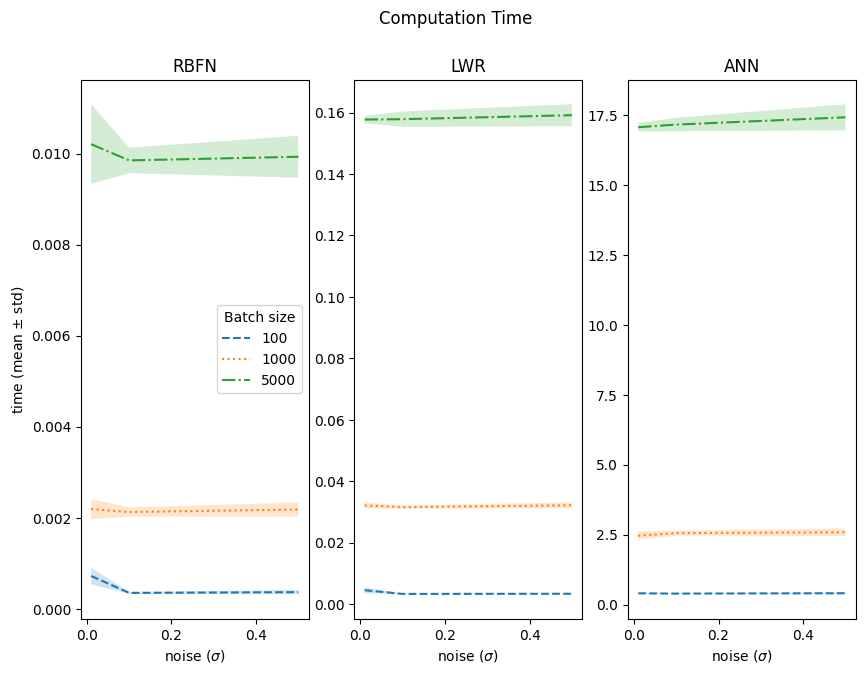

In [390]:
linestyles = ("--", ":", "-.")
model_names = ['RBFN', 'LWR', 'ANN']

fig, axes = plt.subplots(1,3, sharey = False, figsize=(10,7))
axes = axes.flatten()
axes[0].set_ylabel("time (mean $\\pm$ std)")


for m, model_name in enumerate(model_names):
    for i, size in enumerate(sizes): 
        mean = times[model_name][i,:,:].mean(-1)
        std = times[model_name][i,:,:].std(-1)
        axes[m].set_title(model_name)
        axes[m].plot(sigmas, mean, label=str(size), linestyle=linestyles[i])
        axes[m].fill_between(sigmas, mean-std, mean+std, alpha = 0.2)
        axes[m].set_xlabel("noise ($\\sigma$)")
axes[0].legend(title="Batch size")
fig.suptitle("Computation Time")
plt.show()

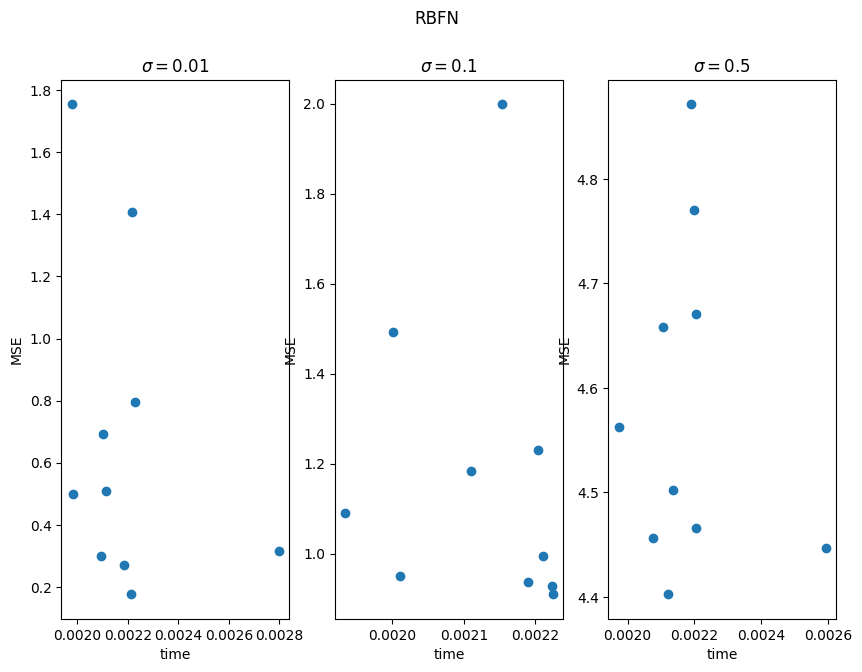

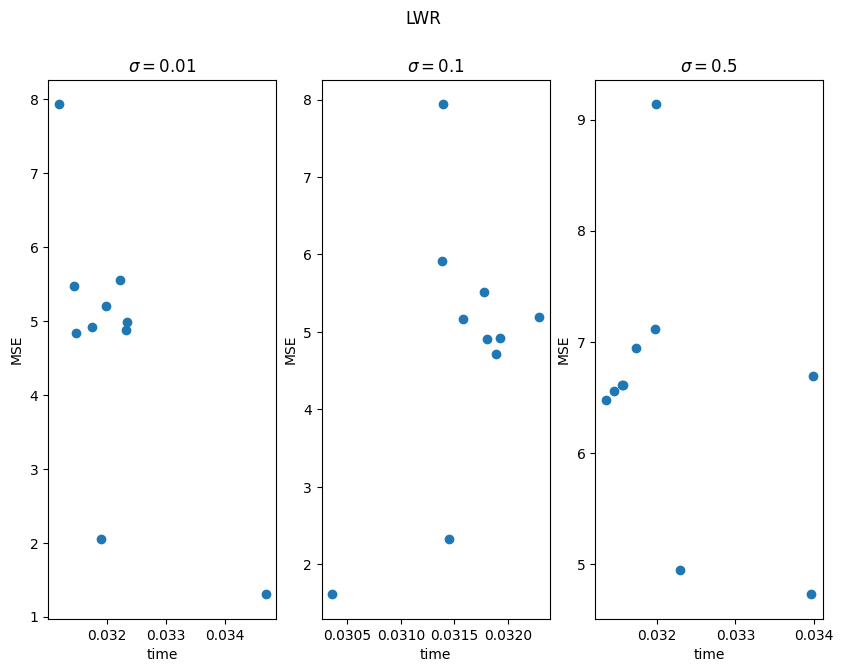

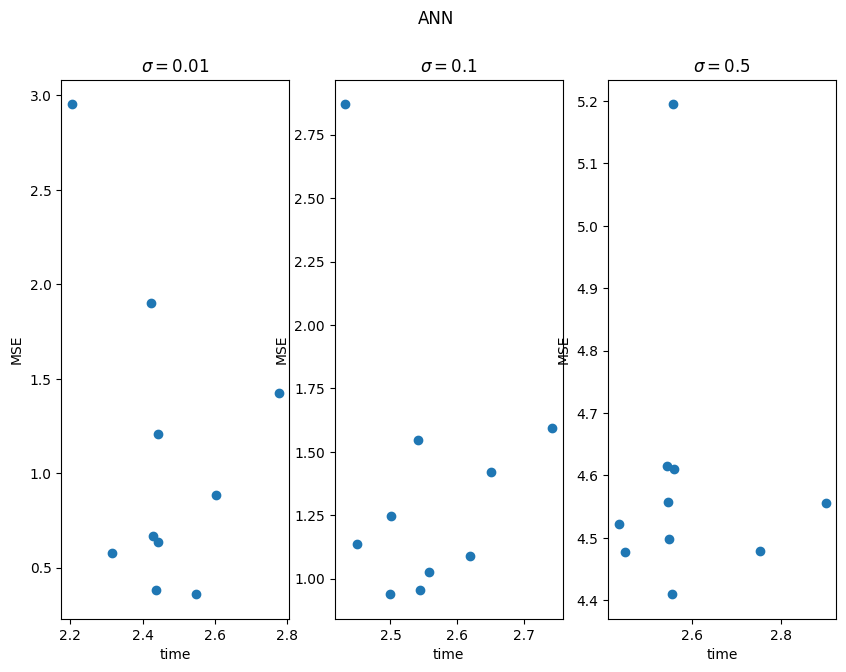

In [391]:
for model_name in model_names:
    fig, axes = plt.subplots(1,3, sharey = False, figsize=(10,7))
    axes = axes.flatten()
    for i, sigma in enumerate(sigmas):
            axes[i].scatter(times[model_name][1,i,:],errors[model_name][1,i,:], label=model_name)
            axes[i].set_title(f"$\\sigma = {sigma}$")
            axes[i].set_ylabel("MSE")
            axes[i].set_xlabel("time")
    fig.suptitle(model_name)

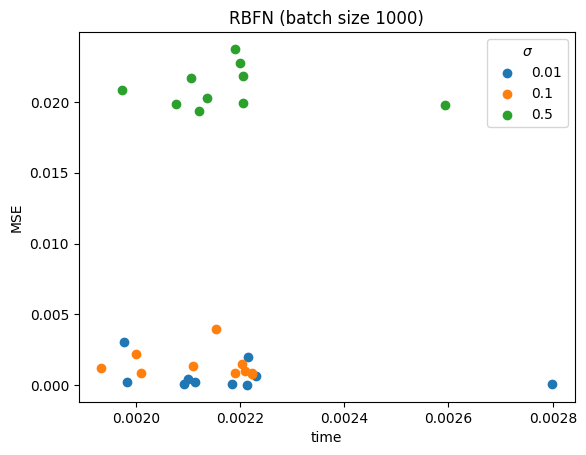

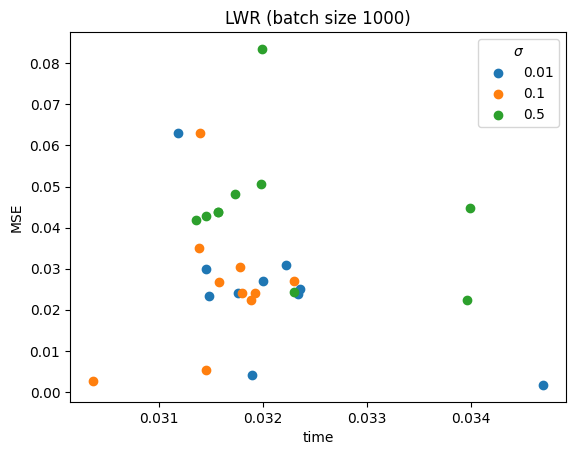

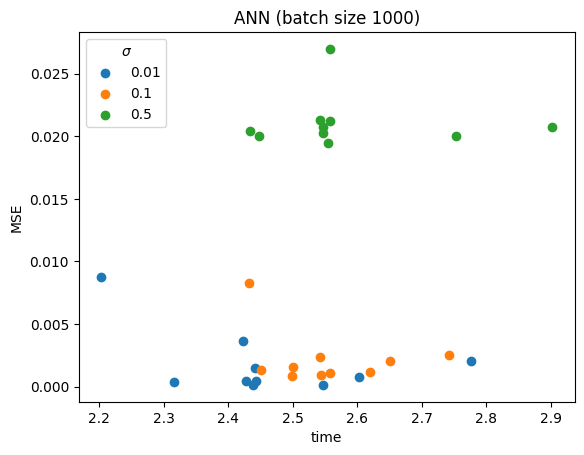

In [392]:
size_idx = 1
for model_name in model_names:
    for i, sigma in enumerate(sigmas):
        plt.scatter(times[model_name][1,i,:],
                    (errors[model_name][size_idx,i,:]**2) / sizes[size_idx], label=str(sigma))

        # plt.title(f"$\\sigma = {sigma}$")
    plt.ylabel("MSE")
    plt.xlabel("time")
    plt.legend(title="$\\sigma$")
    plt.title(f"{model_name} (batch size {sizes[size_idx]})")
    plt.show()

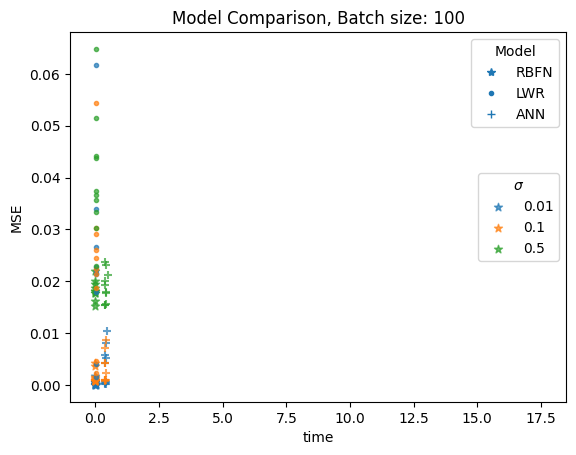

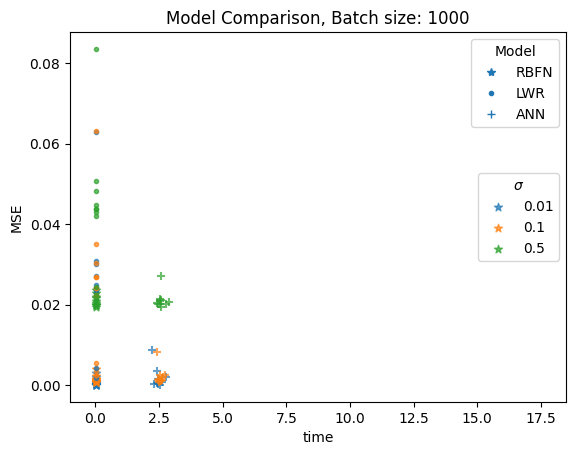

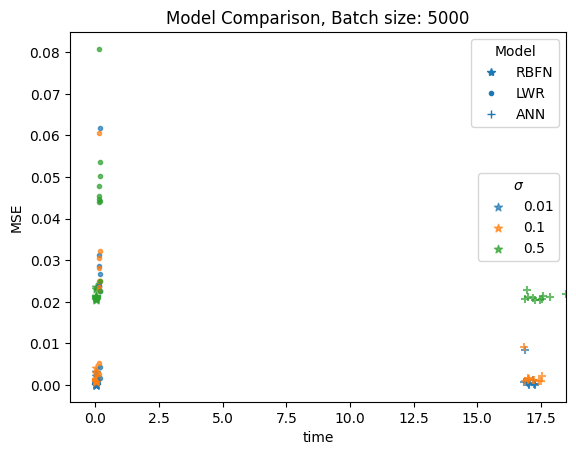

In [393]:
from matplotlib.lines import Line2D
markers = ("*", ".", "+")
colors = plt.cm.tab10.colors  # or any colormap you like
sigma_colors = {sigma: colors[i] for i, sigma in enumerate(sigmas)}
for i, size in enumerate(sizes):
    for m, model_name in enumerate(model_names):
        for j, sigma in enumerate(sigmas):
            plt.scatter(times[model_name][i,j,:],
                        (errors[model_name][i,j,:]**2) / size, label=str(sigma), 
                        marker=markers[m], alpha=0.7, color=sigma_colors[sigma])
            # plt.title(f"$\\sigma = {sigma}$")
    plt.ylabel("MSE")
    plt.xlabel("time")
    plt.legend(title="$\\sigma$")
    plt.title(f"Model Comparison, Batch size: {size}")

    # --- Legend for sigma (colors) ---
    handles_sigma, labels_sigma = plt.gca().get_legend_handles_labels()
    legend_sigma = plt.legend(
        handles_sigma[:len(sigmas)],
        labels_sigma[:len(sigmas)],
        title=r"$\sigma$",
        loc="center right"
    )

    # --- Legend for model (markers) ---
    marker_handles = [
        Line2D(
            [0], [0],
            marker=markers[m],
            linestyle="None",
            label=model_name
        )
        for m, model_name in enumerate(model_names)
    ]

    legend_model = plt.legend(
        handles=marker_handles,
        title="Model",
        loc="upper right"
    )

    # Important: keep both legends
    plt.xlim([-1, np.max([t for key, t in times.items()])])
    # plt.ylim([-1, np.max([e**2 / np.array(sizes).reshape((3,1,1)) for key, e in errors.items()])])
    plt.gca().add_artist(legend_sigma)
    plt.show()